In [1]:
# ============================================================
# 06A — Risk Band Cutoff Discovery
# Part 1:
# Load + invariant checks
# -> 4-variable distribution audit
# -> Train / Validation / OOT fine-bin target gradients
#
# IMPORTANT:
# - No risk-band cutoff is frozen in this notebook section.
# - No feature engineering is written back to the modeling dataset.
# - Train is used for cutoff discovery.
# - Validation / OOT are diagnostic only.
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

# ------------------------------------------------------------
# 1. Resolve project root
# ------------------------------------------------------------

def find_project_root(start=None):
    """
    Walk upward until the expected SFLLD project structure is found.
    This makes the notebook safe to run from either:
        project root/
    or
        project root/notebooks/
    """
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the SFLLD project root. "
        "Expected a parent directory containing both 'data/' and 'notebooks/'."
    )


ROOT = find_project_root()

INPUT = (
    ROOT
    / "data"
    / "output"
    / "final_modeling_dataset"
    / "SFLLD_modeling_dataset_missing_values_treated.parquet"
)

QA_DIR = (
    ROOT
    / "data"
    / "output"
    / "quality_assurance"
    / "06A_risk_band_cutoff_discovery"
)

PLOT_DIR = QA_DIR / "plots"

QA_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT.exists(), f"Input not found: {INPUT.resolve()}"

print("Project root :", ROOT)
print("Input        :", INPUT)
print("QA directory :", QA_DIR)
print("Plot directory:", PLOT_DIR)

Project root : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
Input        : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\final_modeling_dataset\SFLLD_modeling_dataset_missing_values_treated.parquet
QA directory : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery
Plot directory: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\plots


In [2]:
# ============================================================
# 2. Load required columns
# ============================================================

ID_COL = "Loan_ID"
TARGET = "Target_24M"
SPLIT_COL = "Split"

RISK_VARIABLES = [
    "FICO_Score",
    "Original_DTI",
    "Original_LTV",
    "Original_CLTV",
]

REQUIRED_COLUMNS = [
    ID_COL,
    SPLIT_COL,
    TARGET,
    *RISK_VARIABLES,
]

# Inspect parquet schema before loading
schema_cols = pd.read_parquet(INPUT).columns.tolist()

missing_required = [
    c for c in REQUIRED_COLUMNS
    if c not in schema_cols
]

assert not missing_required, (
    f"Required columns missing from dataset: {missing_required}"
)

df = pd.read_parquet(
    INPUT,
    columns=REQUIRED_COLUMNS
)

print("Loaded shape:", df.shape)
display(df.head())

Loaded shape: (713000, 7)


,Loan_ID,Split,Target_24M,FICO_Score,Original_DTI,Original_LTV,Original_CLTV
0,F10Q10000014,Other Period,0,784.0,38.0,80.0,90.0
1,F10Q10000069,Other Period,0,795.0,35.0,67.0,67.0
2,F10Q10000089,Other Period,0,784.0,47.0,55.0,55.0
3,F10Q10000098,Other Period,0,759.0,27.0,50.0,50.0
4,F10Q10000102,Other Period,0,695.0,21.0,50.0,50.0


In [3]:
# ============================================================
# 3. Core invariant checks
# ============================================================

EXPECTED_ROWS = 713_000

print("=" * 80)
print("CORE INVARIANT CHECKS")
print("=" * 80)

# 3.1 Row count
assert len(df) == EXPECTED_ROWS, (
    f"Unexpected row count: {len(df):,}; "
    f"expected {EXPECTED_ROWS:,}"
)

# 3.2 Loan ID integrity
assert df[ID_COL].notna().all(), "Loan_ID contains missing values."

duplicate_loan_ids = int(df[ID_COL].duplicated().sum())

print(f"Rows                : {len(df):,}")
print(f"Unique Loan_ID       : {df[ID_COL].nunique():,}")
print(f"Duplicate Loan_ID    : {duplicate_loan_ids:,}")

assert duplicate_loan_ids == 0, (
    f"Loan_ID is not unique: {duplicate_loan_ids:,} duplicates found."
)

# 3.3 Target integrity
target_values = sorted(df[TARGET].dropna().unique().tolist())

print(f"Target values        : {target_values}")
print(f"Target missing       : {df[TARGET].isna().sum():,}")

assert df[TARGET].notna().all(), "Target_24M contains missing values."
assert set(target_values).issubset({0, 1}), (
    f"Unexpected Target_24M values: {target_values}"
)

# 3.4 Split integrity
print("\nSplit labels:")
display(
    df[SPLIT_COL]
    .value_counts(dropna=False)
    .rename("N")
    .to_frame()
)

assert df[SPLIT_COL].notna().all(), "Split contains missing values."

# Do NOT hard-code labels yet; inspect actual dataset labels
observed_splits = df[SPLIT_COL].astype(str).unique().tolist()

print("Observed split labels:", observed_splits)

# 3.5 Predictor missingness
missing_table = pd.DataFrame({
    "column": RISK_VARIABLES,
    "missing_n": [df[c].isna().sum() for c in RISK_VARIABLES],
    "missing_pct": [
        100 * df[c].isna().mean()
        for c in RISK_VARIABLES
    ],
})

print("\nRisk-variable missingness:")
display(missing_table)

# Missing-value-treated dataset:
# these four predictors should now be complete.
assert (missing_table["missing_n"] == 0).all(), (
    "At least one risk variable still contains missing values."
)

print("\n✓ Core invariant checks passed.")

CORE INVARIANT CHECKS
Rows                : 713,000
Unique Loan_ID       : 713,000
Duplicate Loan_ID    : 0
Target values        : [0, 1]
Target missing       : 0

Split labels:


,N
Split,
Other Period,404240
Train,160003
OOT Test,99719
Validation,49038


Observed split labels: ['Other Period', 'Train', 'Validation', 'OOT Test']

Risk-variable missingness:


,column,missing_n,missing_pct
0,FICO_Score,0,0.0
1,Original_DTI,0,0.0
2,Original_LTV,0,0.0
3,Original_CLTV,0,0.0



✓ Core invariant checks passed.


In [4]:
# ============================================================
# 4. Normalize split labels for analysis
# ============================================================

raw_split_counts = (
    df[SPLIT_COL]
    .astype(str)
    .value_counts()
)

display(raw_split_counts.rename("N").to_frame())

def normalize_split_label(x):
    s = str(x).strip().lower()

    if s in {"train", "training"}:
        return "Train"

    if s in {
        "validation",
        "valid",
        "val",
        "development",
        "dev"
    }:
        return "Validation"

    if s in {
        "oot",
        "out-of-time",
        "out_of_time",
        "out of time",
        "test",
        "oot test",
        "oot_test"
    }:
        return "OOT"

    return str(x).strip()


df["_Split_Analysis"] = (
    df[SPLIT_COL]
    .map(normalize_split_label)
)

print("Normalized split counts:")
display(
    df["_Split_Analysis"]
    .value_counts(dropna=False)
    .rename("N")
    .to_frame()
)

EXPECTED_ANALYSIS_SPLITS = {
    "Train",
    "Validation",
    "OOT",
}

actual_analysis_splits = set(
    df["_Split_Analysis"].unique()
)

unknown_splits = (
    actual_analysis_splits
    - EXPECTED_ANALYSIS_SPLITS
)

if unknown_splits:
    print(
        "WARNING: Unrecognized split labels:",
        unknown_splits
    )

,N
Split,
Other Period,404240
Train,160003
OOT Test,99719
Validation,49038


Normalized split counts:


,N
_Split_Analysis,
Other Period,404240
Train,160003
OOT,99719
Validation,49038


In [5]:
# ============================================================
# 5. Split-level target audit
# ============================================================

split_target_audit = (
    df
    .groupby("_Split_Analysis", observed=True)
    .agg(
        N=(TARGET, "size"),
        Bad_N=(TARGET, "sum"),
        Target_Rate=(TARGET, "mean"),
    )
    .reset_index()
)

split_target_audit["Share_of_Total"] = (
    split_target_audit["N"] / len(df)
)

split_target_audit["Target_Rate_pct"] = (
    100 * split_target_audit["Target_Rate"]
)

split_target_audit["Share_of_Total_pct"] = (
    100 * split_target_audit["Share_of_Total"]
)

display(split_target_audit)

split_target_audit.to_csv(
    QA_DIR / "06A_split_target_audit.csv",
    index=False
)

,_Split_Analysis,N,Bad_N,Target_Rate,Share_of_Total,Target_Rate_pct,Share_of_Total_pct
0,OOT,99719,1753,0.017579,0.139858,1.757940,13.985835
1,Other Period,404240,6666,0.016490,0.566957,1.649020,56.695652
2,Train,160003,919,0.005744,0.224408,0.574364,22.440813
3,Validation,49038,380,0.007749,0.068777,0.774909,6.877700


In [6]:
# ============================================================
# 6. Distribution audit
# ============================================================

QUANTILES = [
    0.00,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00,
]

distribution_rows = []

for split in ["Train", "Validation", "OOT"]:

    sub = df.loc[
        df["_Split_Analysis"] == split
    ]

    if sub.empty:
        continue

    for col in RISK_VARIABLES:

        x = pd.to_numeric(
            sub[col],
            errors="coerce"
        )

        q = x.quantile(QUANTILES)

        row = {
            "Split": split,
            "Variable": col,
            "N": len(x),
            "Missing_N": int(x.isna().sum()),
            "Mean": x.mean(),
            "Std": x.std(),
            "Min": x.min(),
            "P01": q.loc[0.01],
            "P05": q.loc[0.05],
            "P10": q.loc[0.10],
            "P25": q.loc[0.25],
            "Median": q.loc[0.50],
            "P75": q.loc[0.75],
            "P90": q.loc[0.90],
            "P95": q.loc[0.95],
            "P99": q.loc[0.99],
            "Max": x.max(),
            "Unique_N": x.nunique(),
        }

        distribution_rows.append(row)


distribution_audit = pd.DataFrame(
    distribution_rows
)

display(distribution_audit)

distribution_audit.to_csv(
    QA_DIR / "06A_four_variable_distribution_audit.csv",
    index=False
)

,Split,Variable,N,Missing_N,Mean,Std,Min,P01,P05,P10,P25,Median,P75,P90,P95,P99,Max,Unique_N
0,Train,FICO_Score,160003,0,747.923870,48.174816,445.0,622.0,660.0,681.0,715.0,757.0,787.0,802.0,809.0,816.0,834.0,355
1,Train,Original_DTI,160003,0,34.045093,8.833129,1.0,12.0,18.0,21.0,28.0,35.0,41.0,45.0,47.0,50.0,50.0,50
2,Train,Original_LTV,160003,0,74.067111,18.024907,3.0,23.0,39.0,49.0,65.0,79.0,85.0,95.0,95.0,108.0,336.0,209
3,Train,Original_CLTV,160003,0,75.034868,18.408120,3.0,24.0,40.0,50.0,66.0,80.0,87.0,95.0,95.0,115.0,854.0,226
4,Validation,FICO_Score,49038,0,744.718647,47.236297,484.0,626.0,660.0,680.0,711.0,752.0,784.0,801.0,808.0,816.0,832.0,288
5,Validation,Original_DTI,49038,0,35.193442,9.117580,1.0,13.0,19.0,22.0,29.0,36.0,43.0,46.0,48.0,50.0,50.0,50
6,Validation,Original_LTV,49038,0,75.250214,16.927563,6.0,24.0,41.0,51.0,68.0,80.0,88.0,95.0,95.0,97.0,194.0,139
7,Validation,Original_CLTV,49038,0,75.684571,16.879712,6.0,25.0,41.0,51.0,68.0,80.0,90.0,95.0,95.0,97.0,194.0,150
8,OOT,FICO_Score,99719,0,746.180878,45.721928,583.0,630.0,660.0,681.0,715.0,754.0,784.0,800.0,807.0,815.0,848.0,236
9,OOT,Original_DTI,99719,0,37.286615,9.292521,1.0,13.0,20.0,24.0,31.0,39.0,45.0,48.0,50.0,50.0,64.0,62


In [7]:
# ============================================================
# 7. Side-by-side distribution comparison
# ============================================================

for variable in RISK_VARIABLES:

    print("\n")
    print("=" * 90)
    print(variable)
    print("=" * 90)

    temp = (
        distribution_audit
        .loc[
            distribution_audit["Variable"] == variable,
            [
                "Split",
                "N",
                "Mean",
                "Std",
                "Min",
                "P01",
                "P05",
                "P10",
                "P25",
                "Median",
                "P75",
                "P90",
                "P95",
                "P99",
                "Max",
            ]
        ]
        .set_index("Split")
    )

    display(temp.round(3))



FICO_Score


,N,Mean,Std,Min,P01,P05,P10,P25,Median,P75,P90,P95,P99,Max
Split,,,,,,,,,,,,,,
Train,160003,747.924,48.175,445.0,622.0,660.0,681.0,715.0,757.0,787.0,802.0,809.0,816.0,834.0
Validation,49038,744.719,47.236,484.0,626.0,660.0,680.0,711.0,752.0,784.0,801.0,808.0,816.0,832.0
OOT,99719,746.181,45.722,583.0,630.0,660.0,681.0,715.0,754.0,784.0,800.0,807.0,815.0,848.0




Original_DTI


,N,Mean,Std,Min,P01,P05,P10,P25,Median,P75,P90,P95,P99,Max
Split,,,,,,,,,,,,,,
Train,160003,34.045,8.833,1.0,12.0,18.0,21.0,28.0,35.0,41.0,45.0,47.0,50.0,50.0
Validation,49038,35.193,9.118,1.0,13.0,19.0,22.0,29.0,36.0,43.0,46.0,48.0,50.0,50.0
OOT,99719,37.287,9.293,1.0,13.0,20.0,24.0,31.0,39.0,45.0,48.0,50.0,50.0,64.0




Original_LTV


,N,Mean,Std,Min,P01,P05,P10,P25,Median,P75,P90,P95,P99,Max
Split,,,,,,,,,,,,,,
Train,160003,74.067,18.025,3.0,23.0,39.0,49.0,65.0,79.0,85.0,95.0,95.0,108.0,336.0
Validation,49038,75.250,16.928,6.0,24.0,41.0,51.0,68.0,80.0,88.0,95.0,95.0,97.0,194.0
OOT,99719,74.297,18.945,4.0,20.0,35.0,46.0,64.0,80.0,90.0,95.0,95.0,97.0,97.0




Original_CLTV


,N,Mean,Std,Min,P01,P05,P10,P25,Median,P75,P90,P95,P99,Max
Split,,,,,,,,,,,,,,
Train,160003,75.035,18.408,3.0,24.0,40.0,50.0,66.0,80.0,87.0,95.0,95.0,115.0,854.0
Validation,49038,75.685,16.880,6.0,25.0,41.0,51.0,68.0,80.0,90.0,95.0,95.0,97.0,194.0
OOT,99719,74.458,18.995,4.0,20.0,35.0,46.0,64.0,80.0,90.0,95.0,95.0,97.0,105.0


In [8]:
# ============================================================
# 8. Fine-bin definitions
# ============================================================
#
# These are diagnostic bins, NOT final risk-band cutoffs.
#
# FICO : 10-point bins
# DTI  : 5-point bins
# LTV  : 5-point bins
# CLTV : 5-point bins
# ============================================================

FINE_BIN_WIDTH = {
    "FICO_Score": 10,
    "Original_DTI": 5,
    "Original_LTV": 5,
    "Original_CLTV": 5,
}


def make_fixed_width_edges(series, width):
    """
    Generate fixed-width bin edges covering the observed range.
    """

    x = pd.to_numeric(series, errors="coerce")

    observed_min = x.min()
    observed_max = x.max()

    lower = np.floor(observed_min / width) * width
    upper = np.ceil(observed_max / width) * width

    # Guarantee that the maximum falls inside the final interval
    if upper <= observed_max:
        upper += width

    edges = np.arange(
        lower,
        upper + width,
        width
    )

    return edges


# IMPORTANT:
# Use TRAIN to define bin edges.
# Validation/OOT are mapped to the Train-defined structure.
train_mask = df["_Split_Analysis"] == "Train"

assert train_mask.any(), "No Train rows found."

FINE_BIN_EDGES = {}

for variable, width in FINE_BIN_WIDTH.items():

    FINE_BIN_EDGES[variable] = (
        make_fixed_width_edges(
            df.loc[train_mask, variable],
            width
        )
    )

    print(
        variable,
        "->",
        FINE_BIN_EDGES[variable]
    )

FICO_Score -> [440. 450. 460. 470. 480. 490. 500. 510. 520. 530. 540. 550. 560. 570.
 580. 590. 600. 610. 620. 630. 640. 650. 660. 670. 680. 690. 700. 710.
 720. 730. 740. 750. 760. 770. 780. 790. 800. 810. 820. 830. 840.]
Original_DTI -> [ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50. 55.]
Original_LTV -> [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 320. 325. 330. 335. 340.]
Original_CLTV -> [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 32

In [9]:
# ============================================================
# 9. Protect outer bins
# ============================================================
#
# Internal bin boundaries remain Train-derived.
# Only the two outer edges are extended to +/- infinity so
# Validation/OOT observations outside the Train range are not lost.
# ============================================================

for variable in FINE_BIN_EDGES:

    edges = FINE_BIN_EDGES[variable].astype(float).copy()

    edges[0] = -np.inf
    edges[-1] = np.inf

    FINE_BIN_EDGES[variable] = edges

    print(variable)
    print(edges)

FICO_Score
[-inf 450. 460. 470. 480. 490. 500. 510. 520. 530. 540. 550. 560. 570.
 580. 590. 600. 610. 620. 630. 640. 650. 660. 670. 680. 690. 700. 710.
 720. 730. 740. 750. 760. 770. 780. 790. 800. 810. 820. 830.  inf]
Original_DTI
[-inf   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  inf]
Original_LTV
[-inf   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 320. 325. 330. 335.  inf]
Original_CLTV
[-inf   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 32

In [10]:
# ============================================================
# 10. Fine-bin target-gradient function
# ============================================================

def build_target_gradient_table(
    data,
    variable,
    edges,
    target=TARGET,
    split_col="_Split_Analysis",
):
    """
    Create split-specific fine-bin target-gradient statistics.
    """

    temp = data[
        [variable, target, split_col]
    ].copy()

    temp["_Fine_Bin"] = pd.cut(
        pd.to_numeric(
            temp[variable],
            errors="coerce"
        ),
        bins=edges,
        right=False,
        include_lowest=True,
    )

    # Verify every observation was assigned
    assert temp["_Fine_Bin"].notna().all(), (
        f"{variable}: some observations were not assigned to a fine bin."
    )

    result = (
        temp
        .groupby(
            [split_col, "_Fine_Bin"],
            observed=True
        )
        .agg(
            N=(target, "size"),
            Bad_N=(target, "sum"),
            Target_Rate=(target, "mean"),
            Variable_Mean=(variable, "mean"),
            Variable_Min=(variable, "min"),
            Variable_Max=(variable, "max"),
        )
        .reset_index()
    )

    split_totals = (
        result
        .groupby(split_col)["N"]
        .transform("sum")
    )

    result["Pct_of_Split"] = (
        result["N"] / split_totals
    )

    result["Target_Rate_pct"] = (
        100 * result["Target_Rate"]
    )

    result["Pct_of_Split_pct"] = (
        100 * result["Pct_of_Split"]
    )

    result["Variable"] = variable

    return result

In [11]:
# ============================================================
# 11. Generate target-gradient tables
# ============================================================

gradient_tables = {}

for variable in RISK_VARIABLES:

    gradient = build_target_gradient_table(
        data=df,
        variable=variable,
        edges=FINE_BIN_EDGES[variable],
    )

    gradient_tables[variable] = gradient

    print("\n")
    print("=" * 100)
    print(f"FINE-BIN TARGET GRADIENT — {variable}")
    print("=" * 100)

    display(
        gradient[
            [
                "_Split_Analysis",
                "_Fine_Bin",
                "N",
                "Pct_of_Split_pct",
                "Bad_N",
                "Target_Rate_pct",
                "Variable_Min",
                "Variable_Max",
            ]
        ]
    )

    safe_name = variable.lower()

    gradient.to_csv(
        QA_DIR / f"06A_gradient_{safe_name}.csv",
        index=False
    )



FINE-BIN TARGET GRADIENT — FICO_Score


,_Split_Analysis,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Min,Variable_Max
0,OOT,"[580.0, 590.0)",1,0.001003,1,100.000000,583.0,583.0
1,OOT,"[590.0, 600.0)",1,0.001003,0,0.000000,596.0,596.0
2,OOT,"[600.0, 610.0)",53,0.053149,4,7.547170,600.0,609.0
3,OOT,"[610.0, 620.0)",81,0.081228,6,7.407407,610.0,619.0
4,OOT,"[620.0, 630.0)",819,0.821308,79,9.645910,620.0,629.0
5,OOT,"[630.0, 640.0)",937,0.939640,61,6.510139,630.0,639.0
6,OOT,"[640.0, 650.0)",1369,1.372858,95,6.939372,640.0,649.0
7,OOT,"[650.0, 660.0)",1542,1.546345,83,5.382620,650.0,659.0
8,OOT,"[660.0, 670.0)",2248,2.254335,134,5.960854,660.0,669.0
9,OOT,"[670.0, 680.0)",2467,2.473952,98,3.972436,670.0,679.0




FINE-BIN TARGET GRADIENT — Original_DTI


,_Split_Analysis,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Min,Variable_Max
0,OOT,"[-inf, 5.0)",33,0.033093,0,0.000000,1.0,4.0
1,OOT,"[5.0, 10.0)",263,0.263741,3,1.140684,5.0,9.0
2,OOT,"[10.0, 15.0)",1172,1.175303,6,0.511945,10.0,14.0
3,OOT,"[15.0, 20.0)",3214,3.223057,18,0.560050,15.0,19.0
4,OOT,"[20.0, 25.0)",6379,6.396976,60,0.940586,20.0,24.0
5,OOT,"[25.0, 30.0)",9935,9.962996,103,1.036739,25.0,29.0
6,OOT,"[30.0, 35.0)",13658,13.696487,174,1.273979,30.0,34.0
7,OOT,"[35.0, 40.0)",17005,17.052919,280,1.646575,35.0,39.0
8,OOT,"[40.0, 45.0)",22019,22.081048,504,2.288932,40.0,44.0
9,OOT,"[45.0, 50.0)",20847,20.905745,468,2.244927,45.0,49.0




FINE-BIN TARGET GRADIENT — Original_LTV


,_Split_Analysis,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Min,Variable_Max
0,OOT,"[-inf, 5.0)",1,0.001003,0,0.000000,4.0,4.0
1,OOT,"[5.0, 10.0)",46,0.046130,1,2.173913,5.0,9.0
2,OOT,"[10.0, 15.0)",235,0.235662,2,0.851064,10.0,14.0
3,OOT,"[15.0, 20.0)",545,0.546536,2,0.366972,15.0,19.0
4,OOT,"[20.0, 25.0)",897,0.899528,4,0.445931,20.0,24.0
5,OOT,"[25.0, 30.0)",1238,1.241489,15,1.211632,25.0,29.0
6,OOT,"[30.0, 35.0)",1647,1.651641,21,1.275046,30.0,34.0
7,OOT,"[35.0, 40.0)",2059,2.064802,28,1.359883,35.0,39.0
8,OOT,"[40.0, 45.0)",2501,2.508048,25,0.999600,40.0,44.0
9,OOT,"[45.0, 50.0)",2820,2.827947,38,1.347518,45.0,49.0




FINE-BIN TARGET GRADIENT — Original_CLTV


,_Split_Analysis,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Min,Variable_Max
0,OOT,"[-inf, 5.0)",1,0.001003,0,0.000000,4.0,4.0
1,OOT,"[5.0, 10.0)",46,0.046130,1,2.173913,5.0,9.0
2,OOT,"[10.0, 15.0)",232,0.232654,2,0.862069,10.0,14.0
3,OOT,"[15.0, 20.0)",537,0.538513,2,0.372439,15.0,19.0
4,OOT,"[20.0, 25.0)",896,0.898525,4,0.446429,20.0,24.0
5,OOT,"[25.0, 30.0)",1234,1.237477,15,1.215559,25.0,29.0
6,OOT,"[30.0, 35.0)",1635,1.639607,21,1.284404,30.0,34.0
7,OOT,"[35.0, 40.0)",2048,2.053771,28,1.367188,35.0,39.0
8,OOT,"[40.0, 45.0)",2479,2.485986,25,1.008471,40.0,44.0
9,OOT,"[45.0, 50.0)",2805,2.812904,37,1.319073,45.0,49.0


In [12]:
# ============================================================
# 12. TRAIN-only target gradients
# ============================================================

for variable in RISK_VARIABLES:

    print("\n")
    print("=" * 100)
    print(f"TRAIN CUTOFF DISCOVERY TABLE — {variable}")
    print("=" * 100)

    g = gradient_tables[variable]

    train_gradient = (
        g.loc[
            g["_Split_Analysis"] == "Train",
            [
                "_Fine_Bin",
                "N",
                "Pct_of_Split_pct",
                "Bad_N",
                "Target_Rate_pct",
                "Variable_Mean",
                "Variable_Min",
                "Variable_Max",
            ]
        ]
        .copy()
    )

    display(
        train_gradient.round(4)
    )



TRAIN CUTOFF DISCOVERY TABLE — FICO_Score


,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Mean,Variable_Min,Variable_Max
66,"[-inf, 450.0)",1,0.0006,0,0.0000,445.0000,445.0,445.0
67,"[450.0, 460.0)",3,0.0019,1,33.3333,454.6667,454.0,456.0
68,"[460.0, 470.0)",3,0.0019,0,0.0000,462.6667,462.0,464.0
69,"[470.0, 480.0)",3,0.0019,0,0.0000,477.6667,476.0,479.0
70,"[480.0, 490.0)",14,0.0087,0,0.0000,484.6429,481.0,489.0
71,"[490.0, 500.0)",17,0.0106,1,5.8824,494.7059,490.0,498.0
72,"[500.0, 510.0)",15,0.0094,0,0.0000,504.5333,500.0,509.0
73,"[510.0, 520.0)",26,0.0162,1,3.8462,515.4615,511.0,519.0
74,"[520.0, 530.0)",30,0.0187,0,0.0000,524.0333,520.0,529.0
75,"[530.0, 540.0)",44,0.0275,1,2.2727,534.9318,530.0,539.0




TRAIN CUTOFF DISCOVERY TABLE — Original_DTI


,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Mean,Variable_Min,Variable_Max
22,"[-inf, 5.0)",72,0.0450,0,0.0000,2.6944,1.0,4.0
23,"[5.0, 10.0)",603,0.3769,4,0.6633,7.7280,5.0,9.0
24,"[10.0, 15.0)",2766,1.7287,0,0.0000,12.5452,10.0,14.0
25,"[15.0, 20.0)",7971,4.9818,10,0.1255,17.3102,15.0,19.0
26,"[20.0, 25.0)",14427,9.0167,25,0.1733,22.1644,20.0,24.0
27,"[25.0, 30.0)",19619,12.2616,58,0.2956,27.0887,25.0,29.0
28,"[30.0, 35.0)",23763,14.8516,109,0.4587,32.0582,30.0,34.0
29,"[35.0, 40.0)",42352,26.4695,397,0.9374,36.2782,35.0,39.0
30,"[40.0, 45.0)",31129,19.4553,220,0.7067,42.0783,40.0,44.0
31,"[45.0, 50.0)",15294,9.5586,86,0.5623,46.4303,45.0,49.0




TRAIN CUTOFF DISCOVERY TABLE — Original_LTV


,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Mean,Variable_Min,Variable_Max
86,"[-inf, 5.0)",3,0.0019,0,0.0000,3.3333,3.0,4.0
87,"[5.0, 10.0)",75,0.0469,0,0.0000,7.6533,5.0,9.0
88,"[10.0, 15.0)",252,0.1575,0,0.0000,12.4960,10.0,14.0
89,"[15.0, 20.0)",603,0.3769,0,0.0000,17.2139,15.0,19.0
90,"[20.0, 25.0)",1039,0.6494,2,0.1925,22.1963,20.0,24.0
91,"[25.0, 30.0)",1494,0.9337,3,0.2008,27.0977,25.0,29.0
92,"[30.0, 35.0)",2198,1.3737,6,0.2730,32.1533,30.0,34.0
93,"[35.0, 40.0)",2767,1.7293,9,0.3253,37.1041,35.0,39.0
94,"[40.0, 45.0)",3550,2.2187,6,0.1690,42.0969,40.0,44.0
95,"[45.0, 50.0)",4640,2.8999,17,0.3664,47.0912,45.0,49.0




TRAIN CUTOFF DISCOVERY TABLE — Original_CLTV


,_Fine_Bin,N,Pct_of_Split_pct,Bad_N,Target_Rate_pct,Variable_Mean,Variable_Min,Variable_Max
104,"[-inf, 5.0)",2,0.0012,0,0.0000,3.5000,3.0,4.0
105,"[5.0, 10.0)",62,0.0387,0,0.0000,7.7419,5.0,9.0
106,"[10.0, 15.0)",230,0.1437,0,0.0000,12.4957,10.0,14.0
107,"[15.0, 20.0)",554,0.3462,0,0.0000,17.2112,15.0,19.0
108,"[20.0, 25.0)",958,0.5987,2,0.2088,22.1879,20.0,24.0
109,"[25.0, 30.0)",1385,0.8656,2,0.1444,27.0968,25.0,29.0
110,"[30.0, 35.0)",2058,1.2862,4,0.1944,32.1526,30.0,34.0
111,"[35.0, 40.0)",2595,1.6218,9,0.3468,37.1075,35.0,39.0
112,"[40.0, 45.0)",3369,2.1056,5,0.1484,42.0965,40.0,44.0
113,"[45.0, 50.0)",4371,2.7318,15,0.3432,47.0808,45.0,49.0


In [13]:
# ============================================================
# 13. Plot functions
# ============================================================

SPLIT_ORDER = [
    "Train",
    "Validation",
    "OOT",
]


def plot_target_gradient(
    gradient,
    variable,
    save_dir=None
):
    """
    Plot Target_24M rate by fine bin for Train / Validation / OOT.
    """

    fig, ax = plt.subplots(figsize=(14, 6))

    for split in SPLIT_ORDER:

        sub = gradient.loc[
            gradient["_Split_Analysis"] == split
        ].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("_Fine_Bin")

        x = np.arange(len(sub))

        ax.plot(
            x,
            sub["Target_Rate_pct"],
            marker="o",
            label=split,
        )

    # Use Train bins as x labels
    train_sub = (
        gradient.loc[
            gradient["_Split_Analysis"] == "Train"
        ]
        .sort_values("_Fine_Bin")
    )

    labels = (
        train_sub["_Fine_Bin"]
        .astype(str)
        .tolist()
    )

    ax.set_xticks(
        np.arange(len(labels))
    )

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_title(
        f"{variable}: Fine-Bin Target_24M Gradient"
    )

    ax.set_xlabel(
        f"{variable} fine bin"
    )

    ax.set_ylabel(
        "Target_24M rate (%)"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend(
        title="Split"
    )

    plt.tight_layout()

    if save_dir is not None:

        path = (
            Path(save_dir)
            / f"06A_{variable}_target_gradient.png"
        )

        fig.savefig(
            path,
            dpi=160,
            bbox_inches="tight"
        )

    plt.show()


def plot_train_bin_counts(
    gradient,
    variable,
    save_dir=None
):
    """
    Plot Train sample count per fine bin.
    """

    sub = (
        gradient.loc[
            gradient["_Split_Analysis"] == "Train"
        ]
        .sort_values("_Fine_Bin")
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    labels = (
        sub["_Fine_Bin"]
        .astype(str)
        .tolist()
    )

    x = np.arange(len(sub))

    ax.bar(
        x,
        sub["N"]
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_title(
        f"{variable}: Train Sample Size by Fine Bin"
    )

    ax.set_xlabel(
        f"{variable} fine bin"
    )

    ax.set_ylabel(
        "Train N"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    if save_dir is not None:

        path = (
            Path(save_dir)
            / f"06A_{variable}_train_bin_counts.png"
        )

        fig.savefig(
            path,
            dpi=160,
            bbox_inches="tight"
        )

    plt.show()

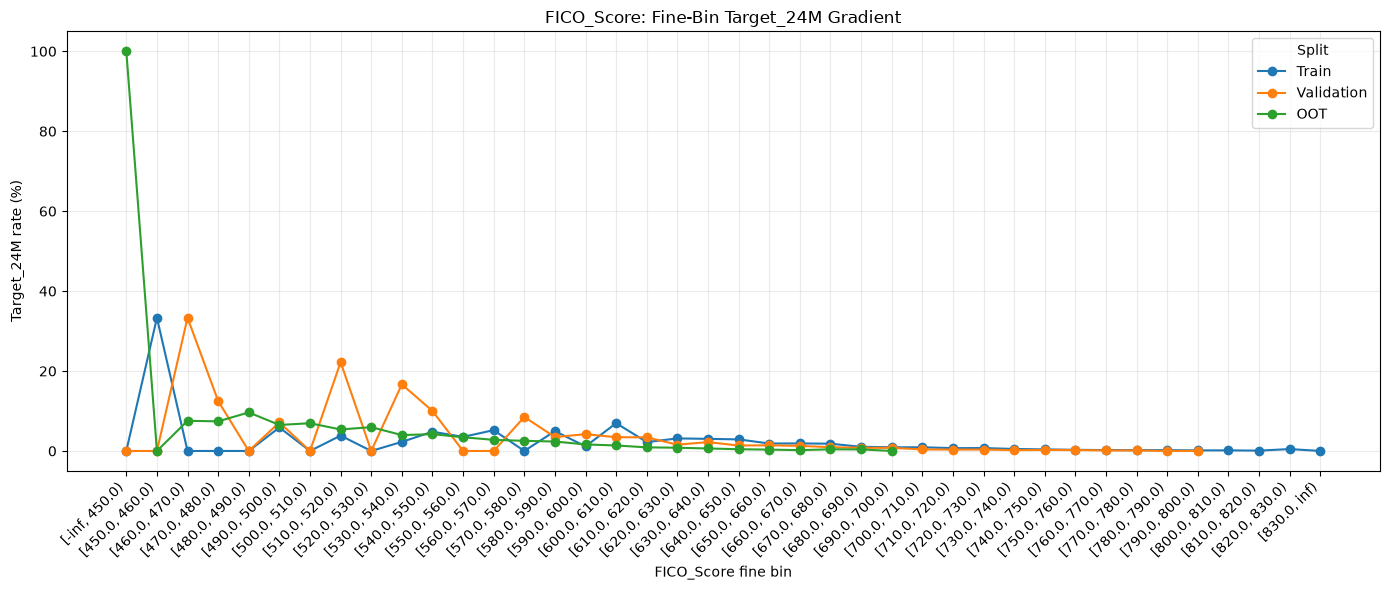

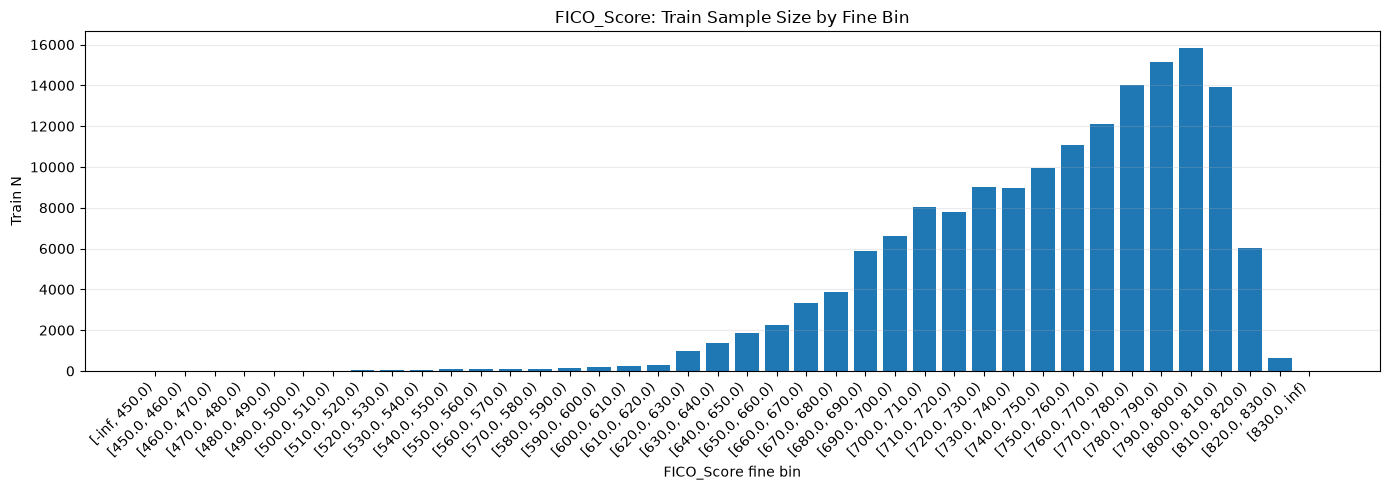

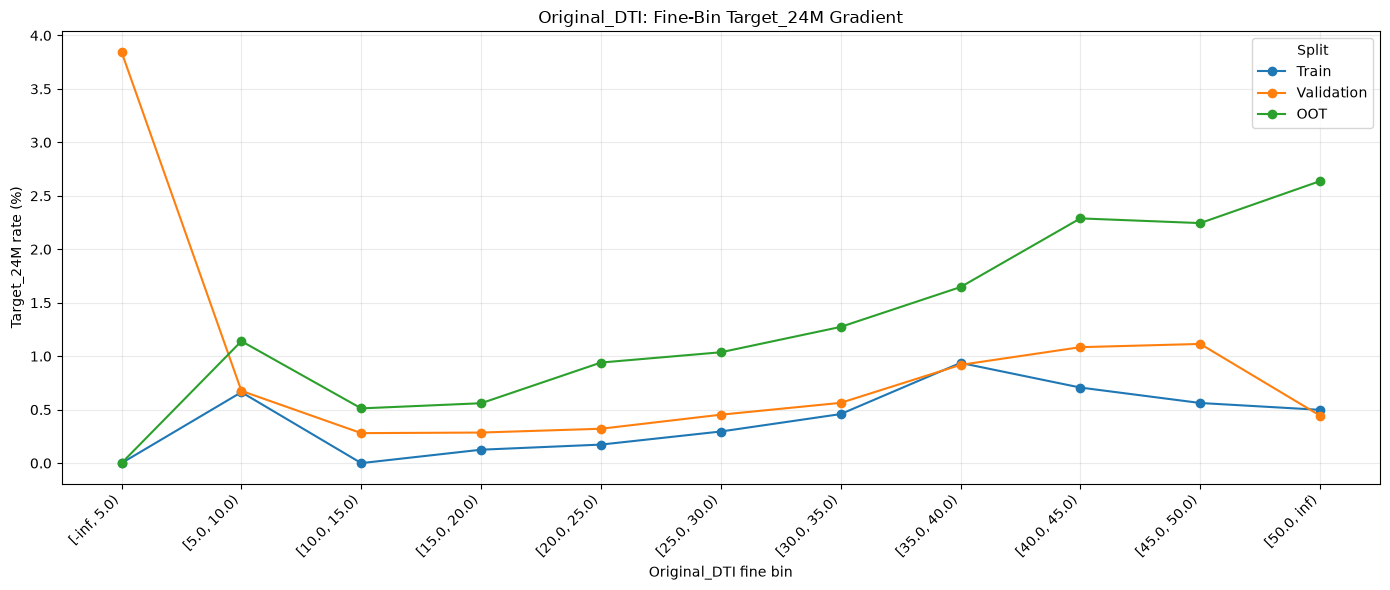

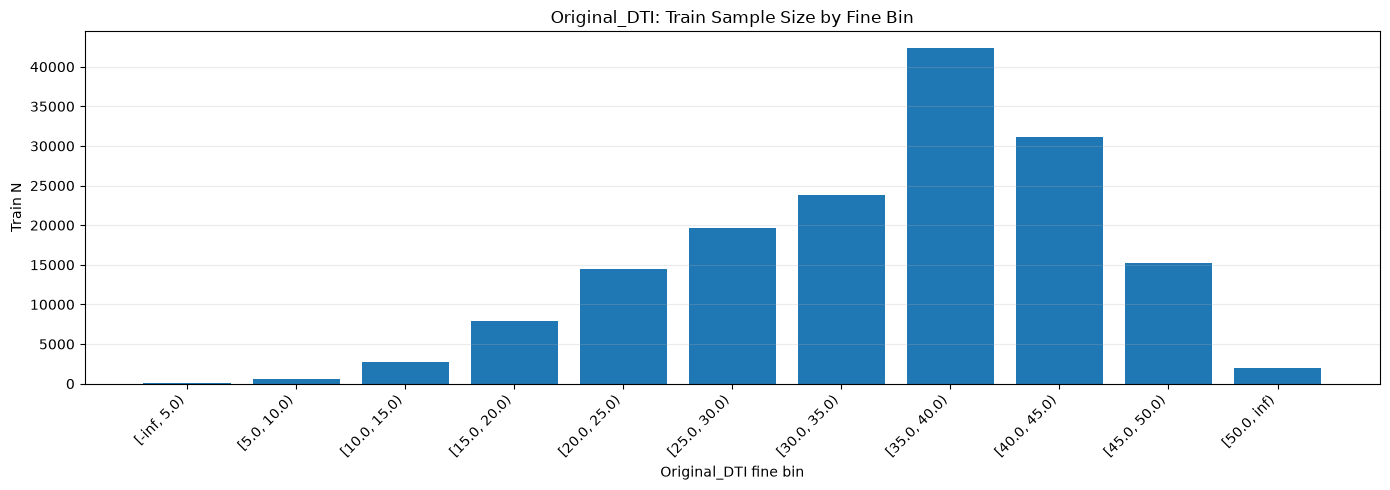

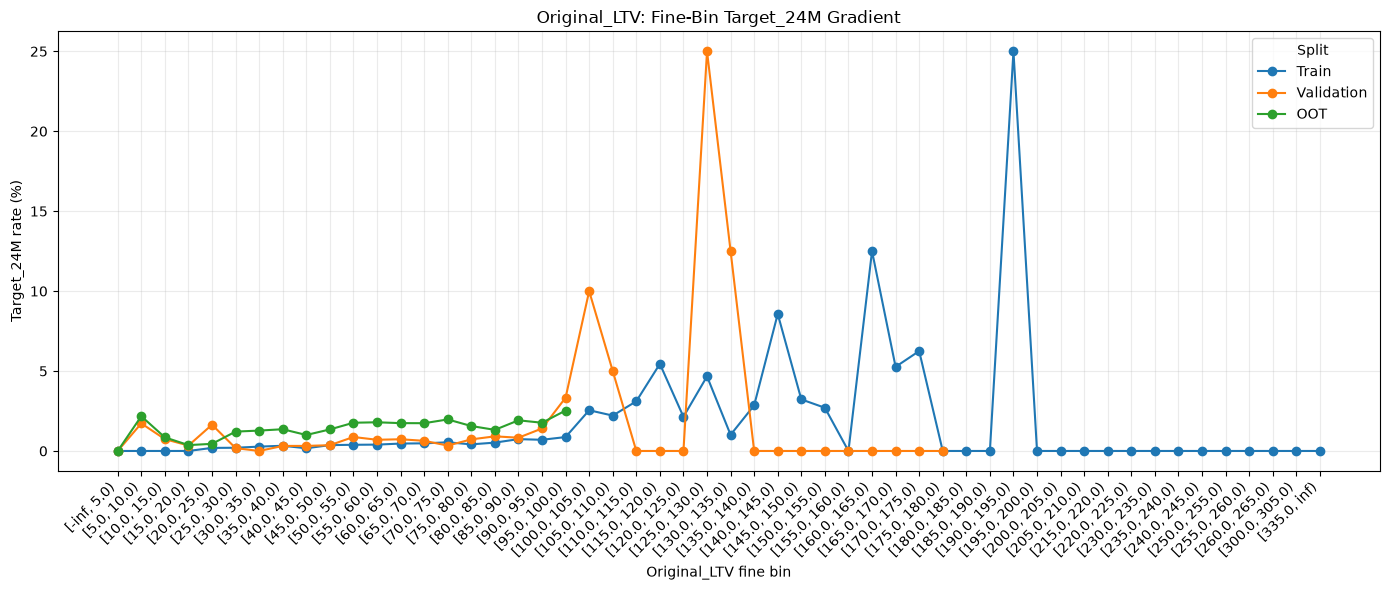

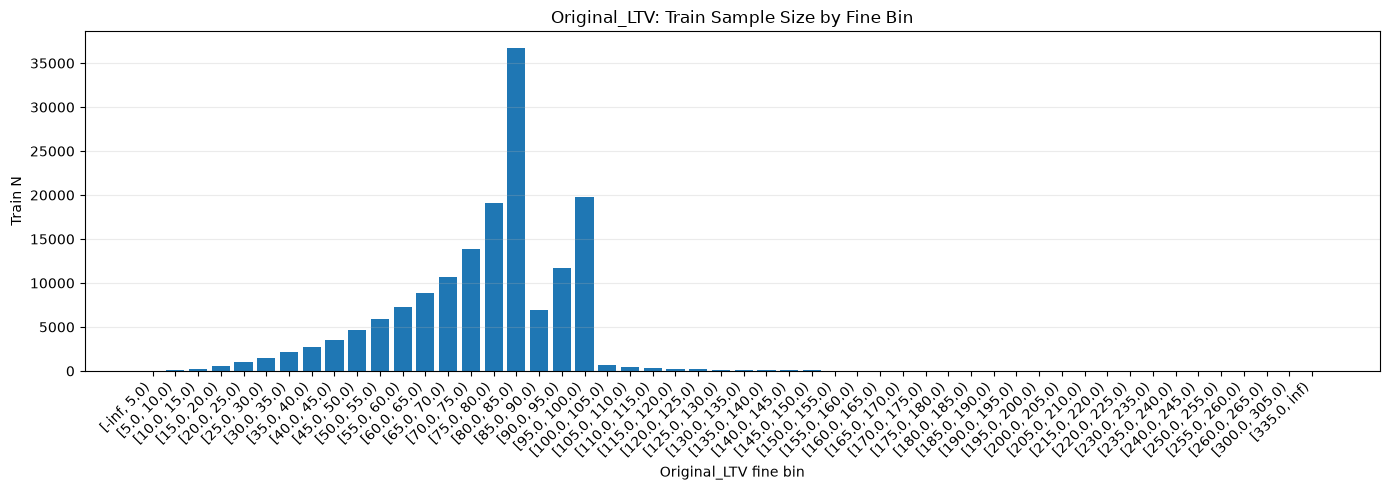

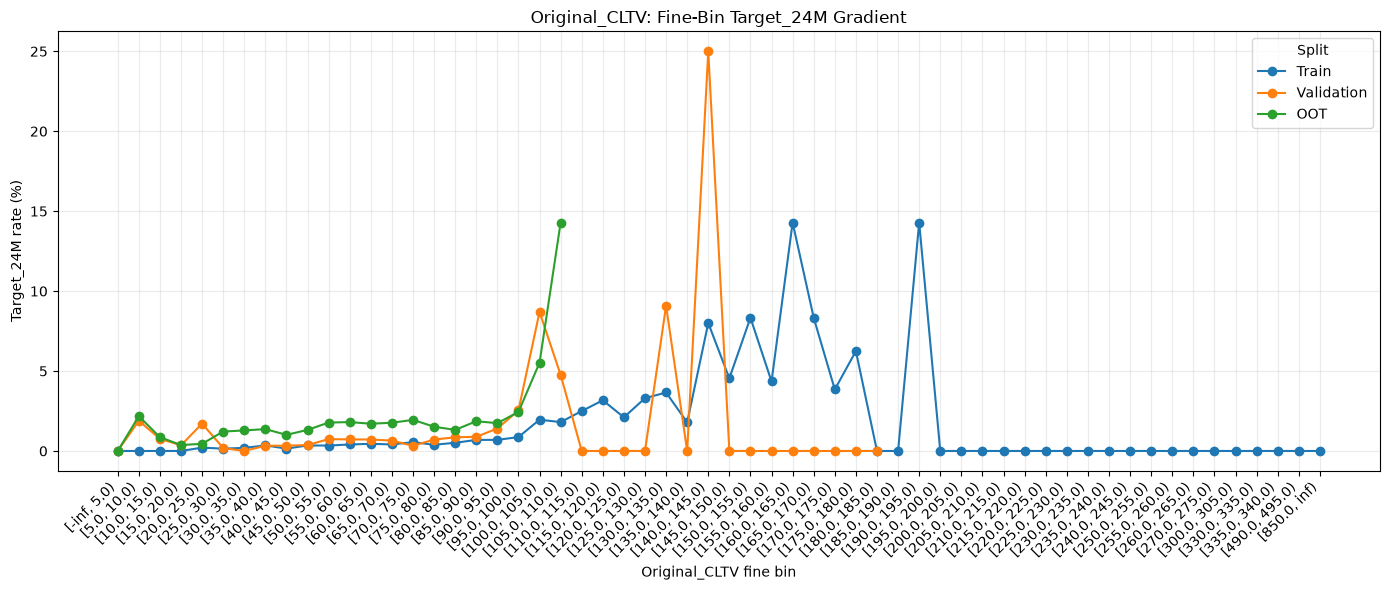

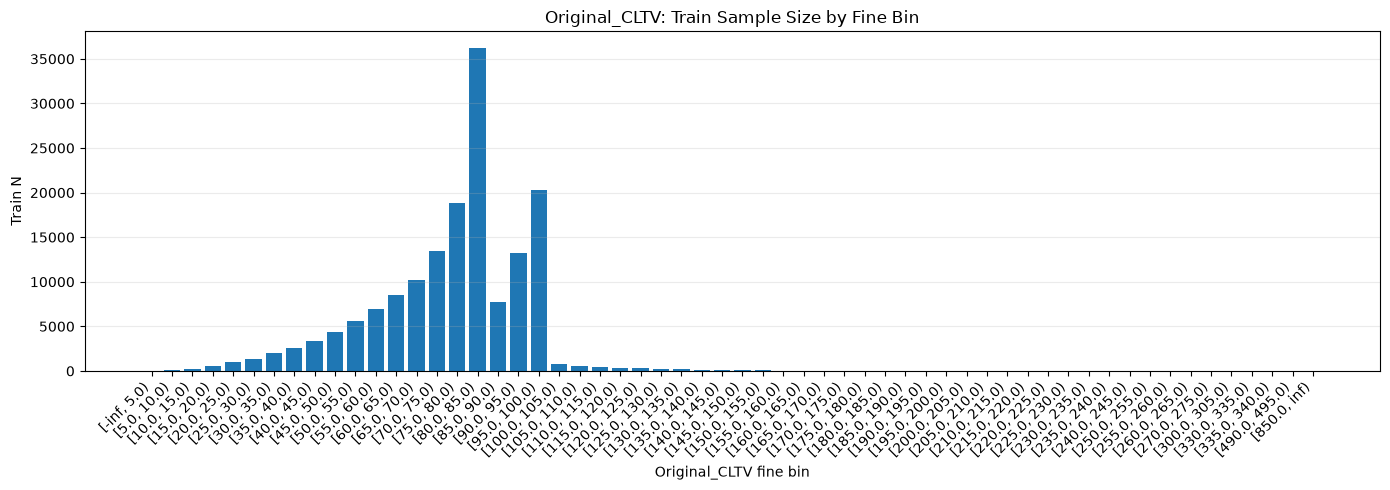

In [14]:
# ============================================================
# 14. Generate target-gradient and sample-size plots
# ============================================================

for variable in RISK_VARIABLES:

    gradient = gradient_tables[variable]

    plot_target_gradient(
        gradient=gradient,
        variable=variable,
        save_dir=PLOT_DIR,
    )

    plot_train_bin_counts(
        gradient=gradient,
        variable=variable,
        save_dir=PLOT_DIR,
    )

In [15]:
# ============================================================
# 15. Combined gradient artifact
# ============================================================

all_gradients = pd.concat(
    gradient_tables.values(),
    ignore_index=True
)

gradient_output = (
    QA_DIR
    / "06A_all_four_variable_fine_bin_target_gradients.csv"
)

all_gradients.to_csv(
    gradient_output,
    index=False
)

print("Saved:", gradient_output)
print("Rows :", len(all_gradients))

Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\06A_all_four_variable_fine_bin_target_gradients.csv
Rows : 559


In [16]:
# ============================================================
# 16. Save fine-bin architecture
# ============================================================

bin_manifest = {}

for variable, edges in FINE_BIN_EDGES.items():

    serializable_edges = []

    for x in edges:

        if np.isneginf(x):
            serializable_edges.append("-inf")

        elif np.isposinf(x):
            serializable_edges.append("+inf")

        else:
            serializable_edges.append(float(x))

    bin_manifest[variable] = {
        "width": FINE_BIN_WIDTH[variable],
        "edges": serializable_edges,
        "purpose": (
            "Diagnostic fine bins for risk-band cutoff discovery; "
            "NOT final frozen risk-band thresholds."
        ),
    }


manifest_path = (
    QA_DIR
    / "06A_fine_bin_manifest.json"
)

manifest_path.write_text(
    json.dumps(
        bin_manifest,
        indent=2
    ),
    encoding="utf-8"
)

print("Saved:", manifest_path)

Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\06A_fine_bin_manifest.json


In [17]:
# ============================================================
# 17. Part-1 QA summary
# ============================================================

summary = {
    "input_file": str(INPUT),
    "rows": int(len(df)),
    "unique_loans": int(df[ID_COL].nunique()),
    "target_column": TARGET,
    "split_column": SPLIT_COL,
    "risk_variables": RISK_VARIABLES,
    "fine_bin_widths": FINE_BIN_WIDTH,
    "cutoff_discovery_split": "Train",
    "validation_role": "confirmation_only",
    "oot_role": "temporal_robustness_check_only",
    "risk_band_cutoffs_frozen": False,
    "feature_engineering_performed": False,
    "source_dataset_modified": False,
}

summary_path = (
    QA_DIR
    / "06A_part1_QA_summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("=" * 90)
print("06A PART 1 COMPLETE")
print("=" * 90)

print(f"Input rows          : {len(df):,}")
print(f"Unique loans        : {df[ID_COL].nunique():,}")
print(f"Risk variables      : {len(RISK_VARIABLES)}")
print(f"Risk bands created  : NO")
print(f"Cutoffs frozen      : NO")
print(f"Dataset modified    : NO")
print()
print("QA artifacts:")
print(QA_DIR)

06A PART 1 COMPLETE
Input rows          : 713,000
Unique loans        : 713,000
Risk variables      : 4
Risk bands created  : NO
Cutoffs frozen      : NO
Dataset modified    : NO

QA artifacts:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery


Using existing DataFrame: df
Shape: (713000, 8)
QA directory: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery


Train rows      : 160,003
Validation rows : 49,038
Train target rate      : 0.574364%
Validation target rate : 0.774909%

FICO — TRAIN CANDIDATE COMPARISON


,Candidate,Variable,Band,N,Bad_N,Target_Rate,Target_Rate_pct,Relative_Risk_vs_Split,Adequate_N,Adequate_Bad_N,Support_OK
0,FICO_C1,FICO_Score,<660,7831,216,0.027583,2.758268,4.802298,True,True,True
1,FICO_C1,FICO_Score,660-699,19659,255,0.012971,1.297116,2.258351,True,True,True
2,FICO_C1,FICO_Score,700-739,33813,240,0.007098,0.709786,1.235777,True,True,True
3,FICO_C1,FICO_Score,740-759,21025,71,0.003377,0.337693,0.587943,True,True,True
4,FICO_C1,FICO_Score,760+,77675,137,0.001764,0.176376,0.307080,True,True,True
5,FICO_C2,FICO_Score,<660,7831,216,0.027583,2.758268,4.802298,True,True,True
6,FICO_C2,FICO_Score,660-679,7186,133,0.018508,1.850821,3.222382,True,True,True
7,FICO_C2,FICO_Score,680-719,28275,251,0.008877,0.887710,1.545552,True,True,True
8,FICO_C2,FICO_Score,720-759,39036,182,0.004662,0.466236,0.811743,True,True,True
9,FICO_C2,FICO_Score,760+,77675,137,0.001764,0.176376,0.307080,True,True,True



DTI — TRAIN CANDIDATE COMPARISON


,Candidate,Variable,Band,N,Bad_N,Target_Rate,Target_Rate_pct,Relative_Risk_vs_Split,Adequate_N,Adequate_Bad_N,Support_OK
0,DTI_C1,Original_DTI,<25,25839,39,0.001509,0.150935,0.262786,True,True,True
1,DTI_C1,Original_DTI,25-34,43382,167,0.003850,0.384952,0.670223,True,True,True
2,DTI_C1,Original_DTI,35-39,42352,397,0.009374,0.937382,1.632034,True,True,True
3,DTI_C1,Original_DTI,40+,48430,316,0.006525,0.652488,1.136018,True,True,True
4,DTI_C2,Original_DTI,<25,25839,39,0.001509,0.150935,0.262786,True,True,True
5,DTI_C2,Original_DTI,25-34,43382,167,0.003850,0.384952,0.670223,True,True,True
6,DTI_C2,Original_DTI,35-39,42352,397,0.009374,0.937382,1.632034,True,True,True
7,DTI_C2,Original_DTI,40-44,31129,220,0.007067,0.706736,1.230467,True,True,True
8,DTI_C2,Original_DTI,45+,17301,96,0.005549,0.554881,0.966079,True,True,True
9,DTI_C3,Original_DTI,<30,45458,97,0.002134,0.213384,0.371513,True,True,True


...

,LTV_Risk_Component,N,Bad_N,Target_Rate,Target_Rate_pct,Relative_Risk_vs_Split,Split
0,LTV_<80,82317,341,0.004143,0.414252,0.721236,Train
1,LTV_80_89,43670,243,0.005564,0.556446,0.968803,Train
2,LTV_90_94,11721,82,0.006996,0.699599,1.218041,Train
3,LTV_95_99,19768,172,0.008701,0.870093,1.514880,Train
4,LTV_100plus,2527,81,0.032054,3.205382,5.580748,Train
5,LTV_<80,22807,122,0.005349,0.534923,0.690305,Validation
6,LTV_80_89,14342,108,0.007530,0.753033,0.971769,Validation
7,LTV_90_94,3736,31,0.008298,0.829764,1.070789,Validation
8,LTV_95_99,8034,113,0.014065,1.406522,1.815080,Validation
9,LTV_100plus,119,6,0.050420,5.042017,6.506590,Validation



CLTV_Risk_Component


,CLTV_Risk_Component,N,Bad_N,Target_Rate,Target_Rate_pct,Relative_Risk_vs_Split,Split
0,CLTV_<80,79015,311,0.003936,0.393596,0.685273,Train
1,CLTV_80_89,43950,239,0.005438,0.543800,0.946786,Train
2,CLTV_90_94,13251,92,0.006943,0.694287,1.208793,Train
3,CLTV_95_99,20270,176,0.008683,0.868278,1.511721,Train
4,CLTV_100plus,3517,101,0.028718,2.871766,4.999903,Train
5,CLTV_<80,22231,117,0.005263,0.526292,0.679166,Validation
6,CLTV_80_89,14433,106,0.007344,0.734428,0.947760,Validation
7,CLTV_90_94,4062,36,0.008863,0.886263,1.143699,Validation
8,CLTV_95_99,8115,114,0.014048,1.404806,1.812865,Validation
9,CLTV_100plus,197,7,0.035533,3.553299,4.585439,Validation



VALIDATION CONFIRMATION SUMMARY


,feature,expected_direction,validation_rank_correlation,severe_extreme_reversal,n_common_bands
0,FICO_Risk_Band,decreasing,1.0,False,5
1,DTI_Risk_Band,increasing,0.8,False,4
2,LTV_Risk_Component,increasing,1.0,False,5
3,CLTV_Risk_Component,increasing,1.0,False,5


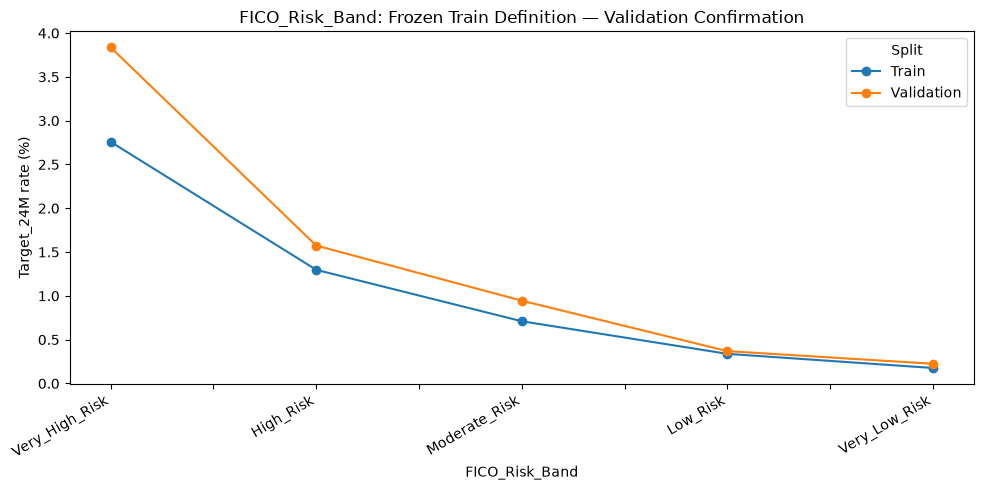

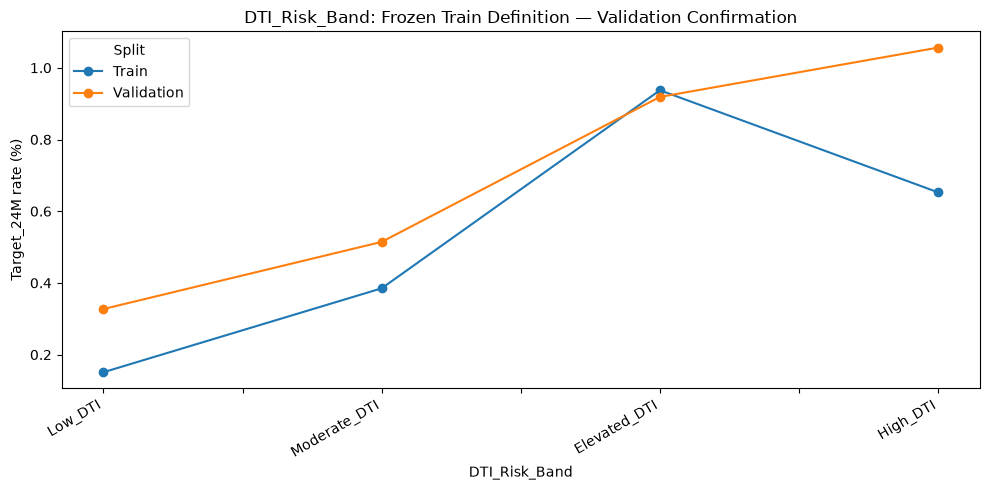

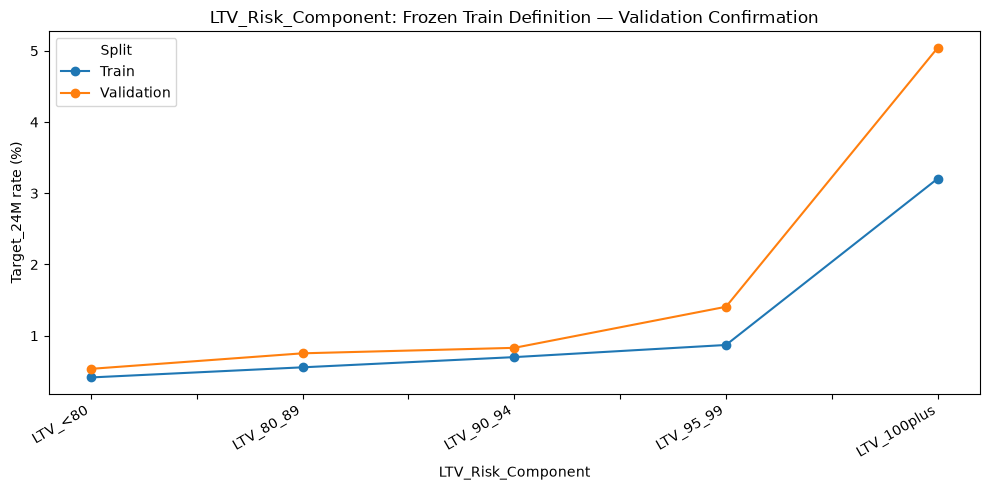

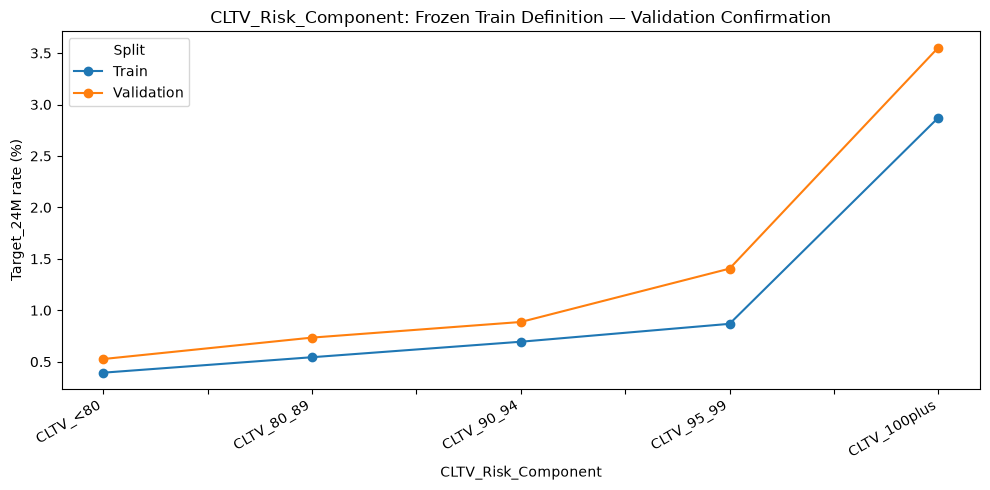


06A PART 2 COMPLETE
Train rows                 : 160,003
Validation rows            : 49,038
OOT used in cutoff choice  : NO
Validation optimized on    : NO
Frozen definitions         : 4
Production dataset modified: NO

Frozen definitions:
  FICO_Risk_Band            ['-inf', 660.0, 700.0, 740.0, 760.0, 'inf']
  DTI_Risk_Band             ['-inf', 25.0, 35.0, 40.0, 'inf']
  LTV_Risk_Component        ['-inf', 80.0, 90.0, 95.0, 100.0, 'inf']
  CLTV_Risk_Component       ['-inf', 80.0, 90.0, 95.0, 100.0, 'inf']

Validation confirmation:


,feature,expected_direction,validation_rank_correlation,severe_extreme_reversal,n_common_bands
0,FICO_Risk_Band,decreasing,1.0,False,5
1,DTI_Risk_Band,increasing,0.8,False,4
2,LTV_Risk_Component,increasing,1.0,False,5
3,CLTV_Risk_Component,increasing,1.0,False,5



Freeze manifest:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\06A_part2_frozen_risk_band_cutoffs.json

QA directory:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery


In [18]:
# =============================================================================
# 06A PART 2
# TRAIN-DERIVED RISK-BAND CUTOFF FREEZE + VALIDATION CONFIRMATION
#
# Methodological rule:
#
# Train
#   -> candidate cutoffs
#   -> coarse-band comparison
#   -> sample-support checks
#   -> mortgage-risk interpretation
#   -> freeze cutoffs
#
# Validation
#   -> confirmation only
#   -> MUST NOT be used to optimize/redefine cutoffs
#
# OOT
#   -> explicitly excluded from cutoff selection in Part 2
#
# No production features are written to the modeling dataset here.
# This notebook/cell only freezes the definitions for later FE.
# =============================================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

# ---------------------------------------------------------------------------
# 1. Reuse df from Part 1, or load the treated modeling dataset
# ---------------------------------------------------------------------------

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    candidates = [start] + list(start.parents)

    for p in candidates:
        if (p / "data").exists():
            return p

    raise FileNotFoundError(
        "Could not locate project root containing the 'data' directory."
    )


ROOT = find_project_root()

INPUT = (
    ROOT
    / "data"
    / "output"
    / "final_modeling_dataset"
    / "SFLLD_modeling_dataset_missing_values_treated.parquet"
)

QA_DIR = (
    ROOT
    / "data"
    / "output"
    / "quality_assurance"
    / "06A_risk_band_cutoff_discovery"
)

QA_DIR.mkdir(parents=True, exist_ok=True)

if "df" not in globals():
    assert INPUT.exists(), f"Input not found: {INPUT.resolve()}"
    df = pd.read_parquet(INPUT)
    print("Loaded:", INPUT.resolve())
else:
    print("Using existing DataFrame: df")

print("Shape:", df.shape)
print("QA directory:", QA_DIR.resolve())


# ---------------------------------------------------------------------------
# 2. Hard invariant checks
# ---------------------------------------------------------------------------

REQUIRED = [
    "Loan_ID",
    "Split",
    "Target_24M",
    "FICO_Score",
    "Original_DTI",
    "Original_LTV",
    "Original_CLTV",
]

missing_required = [c for c in REQUIRED if c not in df.columns]
assert not missing_required, f"Missing required columns: {missing_required}"

assert len(df) == 713_000, f"Unexpected row count: {len(df):,}"
assert df["Loan_ID"].nunique() == len(df), "Loan_ID is not unique."
assert df["Target_24M"].notna().all(), "Target_24M contains missing values."

for c in ["FICO_Score", "Original_DTI", "Original_LTV", "Original_CLTV"]:
    assert df[c].notna().all(), f"{c} still contains missing values."

train = df.loc[df["Split"].astype(str).str.lower().eq("train")].copy()
valid = df.loc[
    df["Split"].astype(str).str.lower().isin(
        ["validation", "valid", "val"]
    )
].copy()

assert len(train) > 0, "Train split not found."
assert len(valid) > 0, "Validation split not found."

print(f"Train rows      : {len(train):,}")
print(f"Validation rows : {len(valid):,}")

print(
    f"Train target rate      : {train['Target_24M'].mean():.6%}"
)
print(
    f"Validation target rate : {valid['Target_24M'].mean():.6%}"
)


# ---------------------------------------------------------------------------
# 3. General aggregation helper
# ---------------------------------------------------------------------------

def summarize_band(data, band_col, target="Target_24M"):
    out = (
        data.groupby(band_col, observed=False)[target]
        .agg(N="size", Bad_N="sum", Target_Rate="mean")
        .reset_index()
    )

    out["Target_Rate_pct"] = out["Target_Rate"] * 100

    overall = data[target].mean()

    out["Relative_Risk_vs_Split"] = np.where(
        overall > 0,
        out["Target_Rate"] / overall,
        np.nan
    )

    return out


def add_support_flags(table, min_n=500, min_bad=10):
    x = table.copy()

    x["Adequate_N"] = x["N"] >= min_n
    x["Adequate_Bad_N"] = x["Bad_N"] >= min_bad

    x["Support_OK"] = (
        x["Adequate_N"] &
        x["Adequate_Bad_N"]
    )

    return x


# ---------------------------------------------------------------------------
# 4. Candidate band definitions
#
# IMPORTANT:
# These are Train-discovered candidate structures.
# Validation is NOT used to search for better thresholds.
# ---------------------------------------------------------------------------

FICO_CANDIDATES = {
    # More compact
    "FICO_C1": {
        "bins": [-np.inf, 660, 700, 740, 760, np.inf],
        "labels": [
            "<660",
            "660-699",
            "700-739",
            "740-759",
            "760+",
        ],
    },

    # Slightly more detailed low-score separation
    "FICO_C2": {
        "bins": [-np.inf, 660, 680, 720, 760, np.inf],
        "labels": [
            "<660",
            "660-679",
            "680-719",
            "720-759",
            "760+",
        ],
    },

    # More conventional broad segmentation
    "FICO_C3": {
        "bins": [-np.inf, 620, 660, 700, 740, 780, np.inf],
        "labels": [
            "<620",
            "620-659",
            "660-699",
            "700-739",
            "740-779",
            "780+",
        ],
    },
}


DTI_CANDIDATES = {
    # Compact structure emphasizing the Train gradient
    "DTI_C1": {
        "bins": [-np.inf, 25, 35, 40, np.inf],
        "labels": [
            "<25",
            "25-34",
            "35-39",
            "40+",
        ],
    },

    # Adds high-DTI separation
    "DTI_C2": {
        "bins": [-np.inf, 25, 35, 40, 45, np.inf],
        "labels": [
            "<25",
            "25-34",
            "35-39",
            "40-44",
            "45+",
        ],
    },

    # Slightly simpler affordability segmentation
    "DTI_C3": {
        "bins": [-np.inf, 30, 35, 40, 45, np.inf],
        "labels": [
            "<30",
            "30-34",
            "35-39",
            "40-44",
            "45+",
        ],
    },
}


LTV_CANDIDATES = {
    "LTV_C1": {
        "bins": [-np.inf, 80, 90, 95, 100, np.inf],
        "labels": [
            "<80",
            "80-89",
            "90-94",
            "95-99",
            "100+",
        ],
    },

    "LTV_C2": {
        "bins": [-np.inf, 80, 95, 100, np.inf],
        "labels": [
            "<80",
            "80-94",
            "95-99",
            "100+",
        ],
    },
}


CLTV_CANDIDATES = {
    "CLTV_C1": {
        "bins": [-np.inf, 80, 90, 95, 100, np.inf],
        "labels": [
            "<80",
            "80-89",
            "90-94",
            "95-99",
            "100+",
        ],
    },

    "CLTV_C2": {
        "bins": [-np.inf, 80, 95, 100, np.inf],
        "labels": [
            "<80",
            "80-94",
            "95-99",
            "100+",
        ],
    },
}


# ---------------------------------------------------------------------------
# 5. Evaluate candidate definitions on TRAIN ONLY
# ---------------------------------------------------------------------------

def evaluate_candidates_train(data, variable, candidates):
    all_tables = []

    for name, spec in candidates.items():

        temp = data[[variable, "Target_24M"]].copy()

        temp["Band"] = pd.cut(
            temp[variable],
            bins=spec["bins"],
            labels=spec["labels"],
            right=False,
            include_lowest=True,
        )

        tab = summarize_band(temp, "Band")
        tab = add_support_flags(tab)

        tab.insert(0, "Candidate", name)
        tab.insert(1, "Variable", variable)

        all_tables.append(tab)

    return pd.concat(all_tables, ignore_index=True)


fico_train_candidates = evaluate_candidates_train(
    train,
    "FICO_Score",
    FICO_CANDIDATES,
)

dti_train_candidates = evaluate_candidates_train(
    train,
    "Original_DTI",
    DTI_CANDIDATES,
)

ltv_train_candidates = evaluate_candidates_train(
    train,
    "Original_LTV",
    LTV_CANDIDATES,
)

cltv_train_candidates = evaluate_candidates_train(
    train,
    "Original_CLTV",
    CLTV_CANDIDATES,
)


print("\n" + "=" * 100)
print("FICO — TRAIN CANDIDATE COMPARISON")
print("=" * 100)
display(fico_train_candidates)

print("\n" + "=" * 100)
print("DTI — TRAIN CANDIDATE COMPARISON")
print("=" * 100)
display(dti_train_candidates)

print("\n" + "=" * 100)
print("LTV — TRAIN CANDIDATE COMPARISON")
print("=" * 100)
display(ltv_train_candidates)

print("\n" + "=" * 100)
print("CLTV — TRAIN CANDIDATE COMPARISON")
print("=" * 100)
display(cltv_train_candidates)


# Save candidate tables
fico_train_candidates.to_csv(
    QA_DIR / "06A_part2_FICO_train_candidate_bands.csv",
    index=False,
)

dti_train_candidates.to_csv(
    QA_DIR / "06A_part2_DTI_train_candidate_bands.csv",
    index=False,
)

ltv_train_candidates.to_csv(
    QA_DIR / "06A_part2_LTV_train_candidate_bands.csv",
    index=False,
)

cltv_train_candidates.to_csv(
    QA_DIR / "06A_part2_CLTV_train_candidate_bands.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 6. TRAIN-only CLTV-LTV gap audit
#
# Purpose:
# Determine whether CLTV contains incremental leverage information
# beyond first-lien LTV.
# ---------------------------------------------------------------------------

train_gap = train[
    ["Original_LTV", "Original_CLTV", "Target_24M"]
].copy()

train_gap["CLTV_LTV_Gap"] = (
    train_gap["Original_CLTV"] -
    train_gap["Original_LTV"]
)

gap_bins = [
    -np.inf,
    0.000001,
    5,
    10,
    20,
    np.inf,
]

gap_labels = [
    "0_or_less",
    "0_to_<5",
    "5_to_<10",
    "10_to_<20",
    "20+",
]

train_gap["Gap_Band"] = pd.cut(
    train_gap["CLTV_LTV_Gap"],
    bins=gap_bins,
    labels=gap_labels,
    right=False,
    include_lowest=True,
)

gap_train_table = summarize_band(
    train_gap,
    "Gap_Band",
)

gap_train_table = add_support_flags(gap_train_table)

print("\n" + "=" * 100)
print("CLTV - LTV GAP — TRAIN")
print("=" * 100)
display(gap_train_table)

gap_train_table.to_csv(
    QA_DIR / "06A_part2_CLTV_LTV_gap_train.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 7. TRAIN-only LTV x CLTV two-dimensional risk matrix
#
# This is intentionally based ONLY on Train.
# ---------------------------------------------------------------------------

LEVERAGE_BINS = [-np.inf, 80, 90, 95, 100, np.inf]

LEVERAGE_LABELS = [
    "<80",
    "80-89",
    "90-94",
    "95-99",
    "100+",
]

lev_train = train[
    ["Original_LTV", "Original_CLTV", "Target_24M"]
].copy()

lev_train["LTV_Band"] = pd.cut(
    lev_train["Original_LTV"],
    bins=LEVERAGE_BINS,
    labels=LEVERAGE_LABELS,
    right=False,
    include_lowest=True,
)

lev_train["CLTV_Band"] = pd.cut(
    lev_train["Original_CLTV"],
    bins=LEVERAGE_BINS,
    labels=LEVERAGE_LABELS,
    right=False,
    include_lowest=True,
)

lev_2d = (
    lev_train
    .groupby(
        ["LTV_Band", "CLTV_Band"],
        observed=False
    )["Target_24M"]
    .agg(
        N="size",
        Bad_N="sum",
        Target_Rate="mean",
    )
    .reset_index()
)

lev_2d["Target_Rate_pct"] = (
    lev_2d["Target_Rate"] * 100
)

lev_2d["Support_OK"] = (
    (lev_2d["N"] >= 500) &
    (lev_2d["Bad_N"] >= 10)
)

print("\n" + "=" * 100)
print("TRAIN LTV × CLTV RISK MATRIX — LONG FORMAT")
print("=" * 100)
display(lev_2d)


rate_matrix = lev_2d.pivot(
    index="LTV_Band",
    columns="CLTV_Band",
    values="Target_Rate_pct",
)

n_matrix = lev_2d.pivot(
    index="LTV_Band",
    columns="CLTV_Band",
    values="N",
)

print("\nTarget rate (%)")
display(rate_matrix)

print("\nSample size (N)")
display(n_matrix)


lev_2d.to_csv(
    QA_DIR / "06A_part2_LTV_CLTV_2D_train.csv",
    index=False,
)

rate_matrix.to_csv(
    QA_DIR / "06A_part2_LTV_CLTV_2D_train_target_rate_matrix.csv"
)

n_matrix.to_csv(
    QA_DIR / "06A_part2_LTV_CLTV_2D_train_N_matrix.csv"
)


# ---------------------------------------------------------------------------
# 8. Freeze definitions
#
# IMPORTANT:
# The freeze below is based on:
#   1) Part-1 Train target gradients
#   2) Train sample support
#   3) mortgage-risk interpretability
#
# Validation has NOT yet been consulted in choosing these boundaries.
#
# If you want to change a frozen definition after inspecting these Train
# tables, change it HERE before running the validation section.
# ---------------------------------------------------------------------------

FROZEN = {

    "FICO_Risk_Band": {
        "source": "FICO_Score",
        "bins": [-np.inf, 660, 700, 740, 760, np.inf],
        "labels": [
            "Very_High_Risk",
            "High_Risk",
            "Moderate_Risk",
            "Low_Risk",
            "Very_Low_Risk",
        ],
        "candidate_source": "FICO_C1",
        "direction": "higher_FICO_expected_lower_risk",
        "rationale": (
            "Train fine-bin Target_24M gradient shows strong inverse "
            "risk ordering with meaningful breaks around 660, 700, "
            "740 and 760 while maintaining adequate sample support."
        ),
    },

    "DTI_Risk_Band": {
        "source": "Original_DTI",
        "bins": [-np.inf, 25, 35, 40, np.inf],
        "labels": [
            "Low_DTI",
            "Moderate_DTI",
            "Elevated_DTI",
            "High_DTI",
        ],
        "candidate_source": "DTI_C1",
        "direction": (
            "higher_DTI_generally_expected_higher_risk_"
            "but_strict_monotonicity_not_required"
        ),
        "rationale": (
            "Train shows increasing risk through the mid/high DTI "
            "range with a pronounced 35-39 regime. The >=40 region "
            "is consolidated rather than over-segmented because the "
            "Train gradient is not strictly monotonic."
        ),
    },

    "LTV_Risk_Component": {
        "source": "Original_LTV",
        "bins": [-np.inf, 80, 90, 95, 100, np.inf],
        "labels": [
            "LTV_<80",
            "LTV_80_89",
            "LTV_90_94",
            "LTV_95_99",
            "LTV_100plus",
        ],
        "candidate_source": "LTV_C1",
        "rationale": (
            "Train leverage gradient supports conventional leverage "
            "breaks with a particularly strong structural transition "
            "at 100 percent."
        ),
    },

    "CLTV_Risk_Component": {
        "source": "Original_CLTV",
        "bins": [-np.inf, 80, 90, 95, 100, np.inf],
        "labels": [
            "CLTV_<80",
            "CLTV_80_89",
            "CLTV_90_94",
            "CLTV_95_99",
            "CLTV_100plus",
        ],
        "candidate_source": "CLTV_C1",
        "rationale": (
            "Train CLTV gradient shows increasing leverage risk and "
            "a strong transition around 100 percent combined leverage."
        ),
    },
}


# ---------------------------------------------------------------------------
# 9. Apply frozen definitions to Train and Validation
#
# This does NOT modify df.
# ---------------------------------------------------------------------------

def apply_frozen_band(data, definition, output_col):
    x = data.copy()

    x[output_col] = pd.cut(
        x[definition["source"]],
        bins=definition["bins"],
        labels=definition["labels"],
        right=False,
        include_lowest=True,
    )

    return x


freeze_results = {}

for feature_name in [
    "FICO_Risk_Band",
    "DTI_Risk_Band",
    "LTV_Risk_Component",
    "CLTV_Risk_Component",
]:

    definition = FROZEN[feature_name]

    tr = apply_frozen_band(
        train[
            [definition["source"], "Target_24M"]
        ],
        definition,
        feature_name,
    )

    va = apply_frozen_band(
        valid[
            [definition["source"], "Target_24M"]
        ],
        definition,
        feature_name,
    )

    tr_tab = summarize_band(
        tr,
        feature_name,
    )

    va_tab = summarize_band(
        va,
        feature_name,
    )

    tr_tab["Split"] = "Train"
    va_tab["Split"] = "Validation"

    combined = pd.concat(
        [tr_tab, va_tab],
        ignore_index=True,
    )

    freeze_results[feature_name] = combined

    print("\n" + "=" * 100)
    print(feature_name)
    print("=" * 100)
    display(combined)

    combined.to_csv(
        QA_DIR / f"06A_part2_{feature_name}_train_validation.csv",
        index=False,
    )


# ---------------------------------------------------------------------------
# 10. Quantitative validation-confirmation diagnostics
#
# Validation is used ONLY after the bands are frozen.
#
# We do NOT require identical rates.
# We examine:
#   - directional association
#   - rank consistency
#   - extreme-band reversal
# ---------------------------------------------------------------------------

def band_confirmation(
    train_table,
    valid_table,
    expected_direction,
):
    """
    expected_direction:
        'increasing' = later bands should generally have higher risk
        'decreasing' = later bands should generally have lower risk
    """

    tr = train_table.copy()
    va = valid_table.copy()

    # Remove empty bands
    tr = tr.loc[tr["N"] > 0].reset_index(drop=True)
    va = va.loc[va["N"] > 0].reset_index(drop=True)

    # Spearman-like rank correlation using pandas ranks
    merged = tr[["Band", "Target_Rate"]].merge(
        va[["Band", "Target_Rate"]],
        on="Band",
        suffixes=("_Train", "_Validation"),
    )

    if len(merged) >= 2:
        rank_corr = (
            merged["Target_Rate_Train"]
            .rank()
            .corr(
                merged["Target_Rate_Validation"].rank()
            )
        )
    else:
        rank_corr = np.nan

    rates = va["Target_Rate"].to_numpy()

    if len(rates) >= 2:
        if expected_direction == "increasing":
            extreme_reversal = bool(
                rates[-1] < rates[0]
            )
        else:
            extreme_reversal = bool(
                rates[-1] > rates[0]
            )
    else:
        extreme_reversal = False

    return {
        "validation_rank_correlation": rank_corr,
        "severe_extreme_reversal": extreme_reversal,
        "n_common_bands": len(merged),
    }


confirmation_rows = []

direction_map = {
    "FICO_Risk_Band": "decreasing",
    "DTI_Risk_Band": "increasing",
    "LTV_Risk_Component": "increasing",
    "CLTV_Risk_Component": "increasing",
}

for feature_name, combined in freeze_results.items():

    tr_tab = (
        combined.loc[combined["Split"] == "Train"]
        .rename(columns={feature_name: "Band"})
        .copy()
    )

    va_tab = (
        combined.loc[combined["Split"] == "Validation"]
        .rename(columns={feature_name: "Band"})
        .copy()
    )

    result = band_confirmation(
        tr_tab,
        va_tab,
        direction_map[feature_name],
    )

    confirmation_rows.append({
        "feature": feature_name,
        "expected_direction": direction_map[feature_name],
        **result,
    })


confirmation_table = pd.DataFrame(
    confirmation_rows
)

print("\n" + "=" * 100)
print("VALIDATION CONFIRMATION SUMMARY")
print("=" * 100)
display(confirmation_table)

confirmation_table.to_csv(
    QA_DIR / "06A_part2_validation_confirmation_summary.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 11. Plot frozen Train vs Validation bands
# ---------------------------------------------------------------------------

for feature_name, combined in freeze_results.items():

    pivot = combined.pivot(
        index=feature_name,
        columns="Split",
        values="Target_Rate_pct",
    )

    ax = pivot.plot(
        marker="o",
        figsize=(10, 5),
    )

    ax.set_title(
        f"{feature_name}: Frozen Train Definition — Validation Confirmation"
    )
    ax.set_ylabel("Target_24M rate (%)")
    ax.set_xlabel(feature_name)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        QA_DIR / f"06A_part2_{feature_name}_validation_confirmation.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


# ---------------------------------------------------------------------------
# 12. Freeze manifest
#
# Convert infinities to JSON-safe strings.
# ---------------------------------------------------------------------------

def json_safe_bins(bins):
    out = []

    for x in bins:
        if x == np.inf:
            out.append("inf")
        elif x == -np.inf:
            out.append("-inf")
        else:
            out.append(float(x))

    return out


freeze_manifest = {
    "stage": "06A_Part_2_risk_band_cutoff_freeze",

    "methodology": {
        "cutoff_discovery_dataset": "Train only",
        "cutoff_freeze_dataset": "Train only",
        "validation_role": "confirmation only",
        "validation_used_to_optimize_cutoffs": False,
        "oot_used_for_cutoff_selection": False,
        "oot_used_for_feature_engineering": False,
        "other_period_used_for_cutoff_selection": False,
    },

    "frozen_definitions": {},

    "validation_confirmation": confirmation_table.to_dict(
        orient="records"
    ),
}


for name, spec in FROZEN.items():

    freeze_manifest["frozen_definitions"][name] = {
        **spec,
        "bins": json_safe_bins(spec["bins"]),
    }


manifest_path = (
    QA_DIR
    / "06A_part2_frozen_risk_band_cutoffs.json"
)

manifest_path.write_text(
    json.dumps(
        freeze_manifest,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


# ---------------------------------------------------------------------------
# 13. Final methodological assertions
# ---------------------------------------------------------------------------

# We must have frozen definitions.
assert len(FROZEN) == 4

# Validation exists, but has not entered the candidate-search functions.
assert len(valid) > 0

# No production feature columns should have been added to original df.
for c in [
    "FICO_Risk_Band",
    "DTI_Risk_Band",
    "LTV_Risk_Component",
    "CLTV_Risk_Component",
]:
    assert c not in df.columns, (
        f"{c} was unexpectedly added to the original modeling dataset."
    )

# Ensure every frozen band has full coverage in both Train and Validation.
for feature_name, definition in FROZEN.items():

    tr_check = pd.cut(
        train[definition["source"]],
        bins=definition["bins"],
        labels=definition["labels"],
        right=False,
        include_lowest=True,
    )

    va_check = pd.cut(
        valid[definition["source"]],
        bins=definition["bins"],
        labels=definition["labels"],
        right=False,
        include_lowest=True,
    )

    assert tr_check.notna().all(), (
        f"{feature_name}: Train coverage failure."
    )

    assert va_check.notna().all(), (
        f"{feature_name}: Validation coverage failure."
    )


print("\n" + "=" * 100)
print("06A PART 2 COMPLETE")
print("=" * 100)

print(f"Train rows                 : {len(train):,}")
print(f"Validation rows            : {len(valid):,}")
print("OOT used in cutoff choice  : NO")
print("Validation optimized on    : NO")
print("Frozen definitions         :", len(FROZEN))
print("Production dataset modified: NO")

print("\nFrozen definitions:")

for name, spec in FROZEN.items():
    print(
        f"  {name:<25} "
        f"{json_safe_bins(spec['bins'])}"
    )

print("\nValidation confirmation:")
display(confirmation_table)

print("\nFreeze manifest:")
print(manifest_path.resolve())

print("\nQA directory:")
print(QA_DIR.resolve())

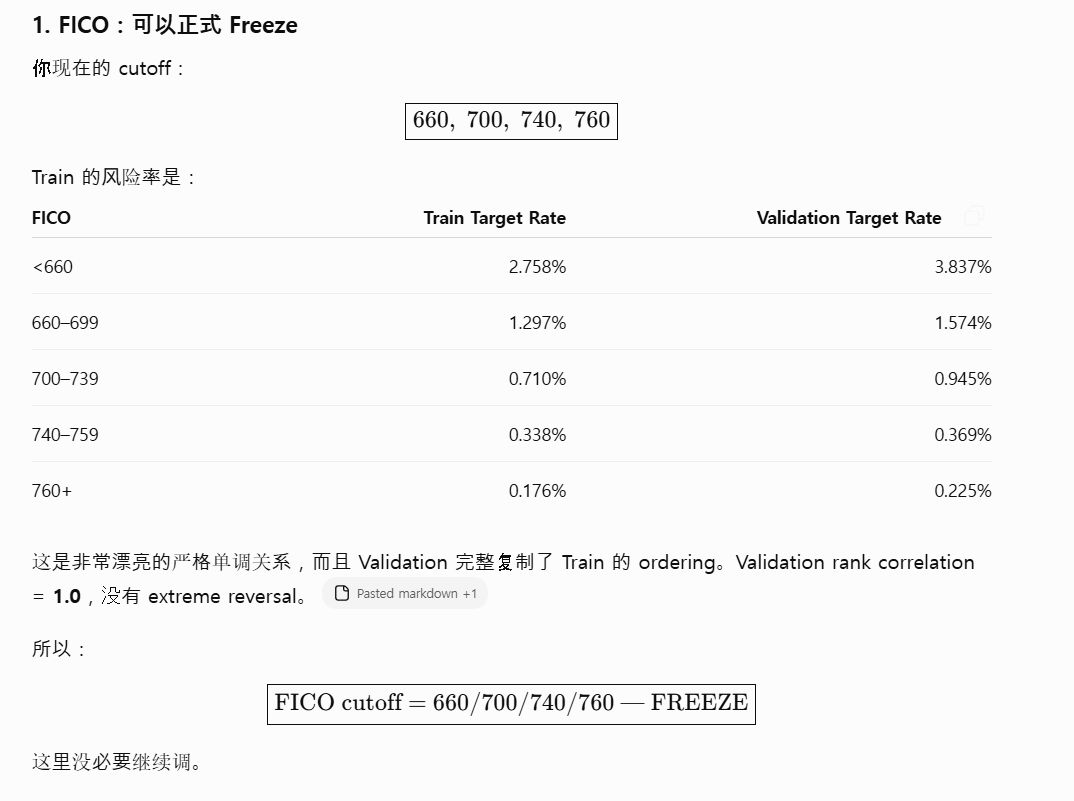

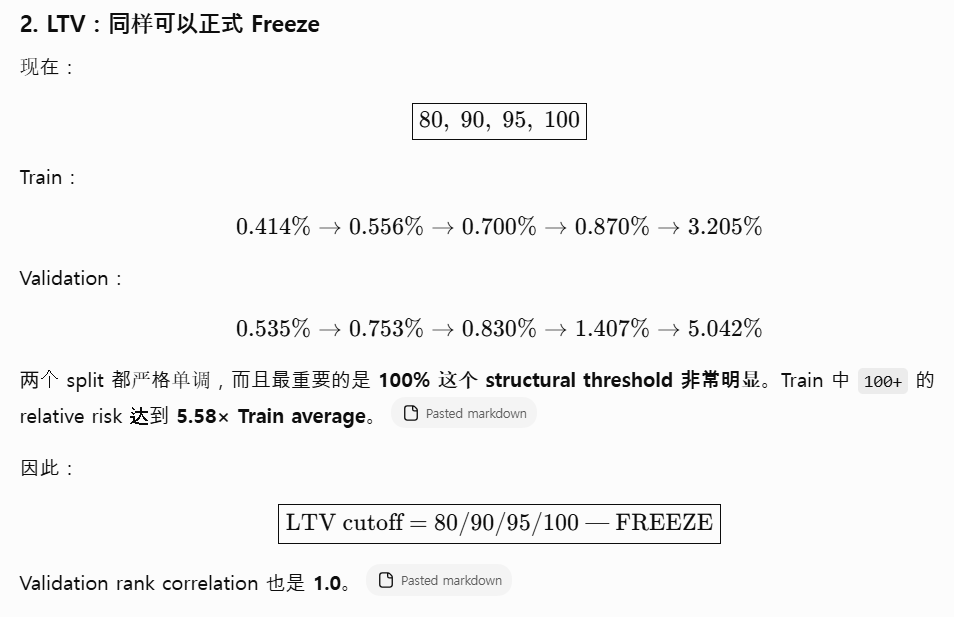

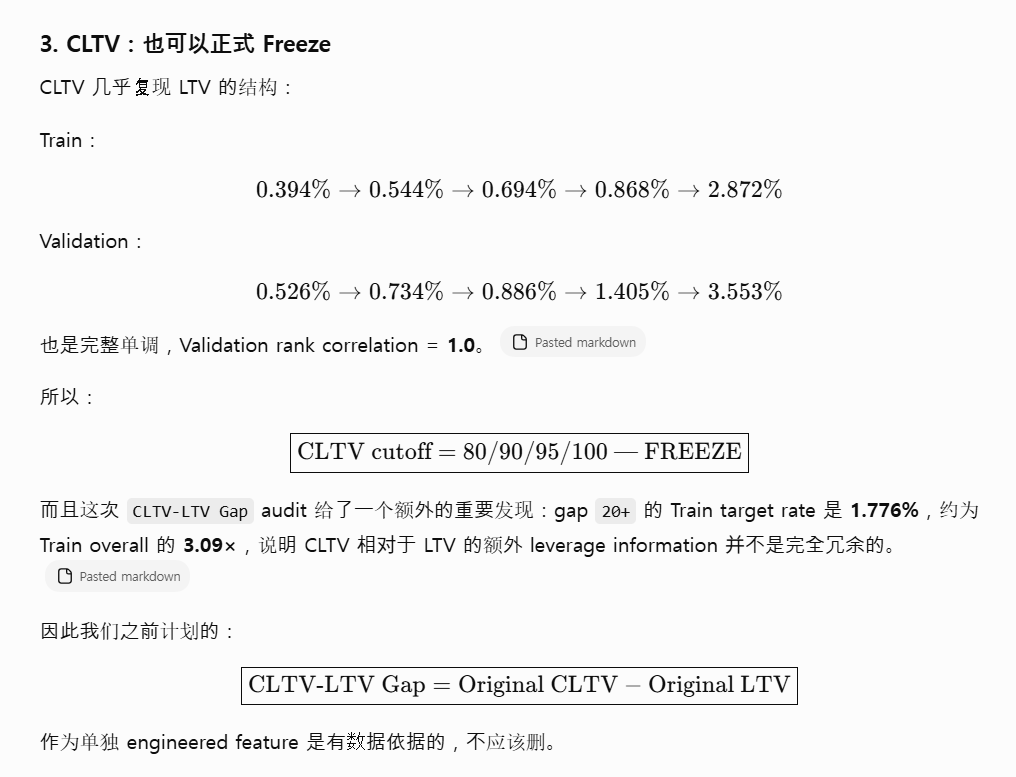

In [19]:
# ======================================================================================
# 06A PART 2B — DTI MISSINGNESS SENSITIVITY AUDIT
#
# Purpose
# -------
# Investigate whether the non-monotonic Train target gradient observed for
# DTI_Risk_Band is partly driven by loans whose Original_DTI was originally
# missing and subsequently imputed to the Train median (35).
#
# IMPORTANT:
#   - Train defines / diagnoses the feature.
#   - Validation is confirmation only.
#   - OOT is NOT used.
#   - No cutoff optimization is performed here.
#   - No production dataset is modified.
#
# Questions answered
# ------------------
# 1. How many loans in each DTI band were originally missing?
# 2. Is the 35–39 Train risk peak driven by DTI-missing loans?
# 3. What is the target rate among originally missing vs observed DTI?
# 4. What does the DTI gradient look like using OBSERVED DTI only?
# 5. Should the final design be:
#       A) DTI_Risk_Band + DTI_Missing
#       B) DTI_Risk_Band + DTI_Missing + DTI_Risk_Band_Adjusted
#
# This notebook section is diagnostic only.
# ======================================================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("=" * 100)
print("06A PART 2B — DTI MISSINGNESS SENSITIVITY AUDIT")
print("=" * 100)

06A PART 2B — DTI MISSINGNESS SENSITIVITY AUDIT


In [20]:
# ======================================================================================
# PATHS
# ======================================================================================

def find_project_root(start=None):
    """
    Find the project root by searching upward for:
        data/output/final_modeling_dataset
    """
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start] + list(start.parents):
        expected = candidate / "data" / "output" / "final_modeling_dataset"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root containing "
        "'data/output/final_modeling_dataset'."
    )


ROOT = find_project_root()

INPUT = (
    ROOT
    / "data"
    / "output"
    / "final_modeling_dataset"
    / "SFLLD_modeling_dataset_missing_values_treated.parquet"
)

QA_DIR = (
    ROOT
    / "data"
    / "output"
    / "quality_assurance"
    / "06A_risk_band_cutoff_discovery"
    / "part_2B_DTI_missingness_sensitivity"
)

QA_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT.exists(), f"Input file not found: {INPUT}"

print("Project root :", ROOT.resolve())
print("Input        :", INPUT.resolve())
print("QA directory :", QA_DIR.resolve())

Project root : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
Input        : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\final_modeling_dataset\SFLLD_modeling_dataset_missing_values_treated.parquet
QA directory : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\part_2B_DTI_missingness_sensitivity


In [21]:
# ======================================================================================
# LOAD DATA + INVARIANT CHECKS
# ======================================================================================

df = pd.read_parquet(INPUT)

print(f"Shape: {df.shape:,}" if False else f"Shape: {df.shape}")
print(f"Rows : {len(df):,}")
print(f"Cols : {df.shape[1]:,}")

required = [
    "Loan_ID",
    "Split",
    "Target_24M",
    "Original_DTI",
    "DTI_Missing",
]

missing_required = [c for c in required if c not in df.columns]

assert not missing_required, (
    f"Required columns missing from dataset: {missing_required}"
)

assert df["Loan_ID"].notna().all(), "Loan_ID contains missing values."
assert df["Loan_ID"].is_unique, "Loan_ID is not unique."
assert df["Target_24M"].isin([0, 1]).all(), "Target_24M must be binary."
assert df["Original_DTI"].notna().all(), (
    "Original_DTI still contains missing values after treatment."
)

print("\nSplit distribution:")
display(df["Split"].value_counts(dropna=False).to_frame("N"))

print("\nDTI_Missing raw values:")
display(df["DTI_Missing"].value_counts(dropna=False).to_frame("N"))

Shape: (713000, 110)
Rows : 713,000
Cols : 110

Split distribution:


,N
Split,
Other Period,404240
Train,160003
OOT Test,99719
Validation,49038



DTI_Missing raw values:


,N
DTI_Missing,
0,634974
1,78026


In [22]:
# ======================================================================================
# NORMALIZE DTI_MISSING
# ======================================================================================

raw_missing = df["DTI_Missing"].astype("string").str.strip()

print("Observed raw DTI_Missing categories:")
print(sorted(raw_missing.dropna().unique().tolist()))


def normalize_dti_missing(series):
    """
    Convert common representations of DTI missingness into:
        Observed
        Missing
    """

    s = series.astype("string").str.strip().str.lower()

    missing_values = {
        "missing",
        "yes",
        "y",
        "1",
        "true",
        "originally_missing",
    }

    observed_values = {
        "observed",
        "no",
        "n",
        "0",
        "false",
        "not_missing",
    }

    out = pd.Series(pd.NA, index=series.index, dtype="string")

    out.loc[s.isin(missing_values)] = "Missing"
    out.loc[s.isin(observed_values)] = "Observed"

    return out


df["_DTI_Missing_Status"] = normalize_dti_missing(df["DTI_Missing"])

unmapped = df.loc[
    df["_DTI_Missing_Status"].isna(),
    "DTI_Missing"
].value_counts(dropna=False)

if len(unmapped) > 0:
    print("\nUNMAPPED DTI_Missing values:")
    display(unmapped.to_frame("N"))

assert df["_DTI_Missing_Status"].notna().all(), (
    "Some DTI_Missing values could not be normalized. "
    "Inspect the displayed categories before continuing."
)

print("\nNormalized DTI missingness:")
display(
    df["_DTI_Missing_Status"]
    .value_counts()
    .rename_axis("DTI_Missing_Status")
    .to_frame("N")
)

Observed raw DTI_Missing categories:
['0', '1']

Normalized DTI missingness:


,N
DTI_Missing_Status,
Observed,634974
Missing,78026


In [23]:
# ======================================================================================
# RECREATE FROZEN DTI RISK BAND
#
# Frozen in 06A Part 2:
#   <25
#   25–34
#   35–39
#   40+
# ======================================================================================

DTI_BINS = [-np.inf, 25, 35, 40, np.inf]

DTI_LABELS = [
    "Low_DTI",
    "Moderate_DTI",
    "Elevated_DTI",
    "High_DTI",
]

df["_DTI_Risk_Band_Audit"] = pd.cut(
    pd.to_numeric(df["Original_DTI"], errors="coerce"),
    bins=DTI_BINS,
    labels=DTI_LABELS,
    right=False,
    ordered=True,
)

assert df["_DTI_Risk_Band_Audit"].notna().all(), (
    "Some treated Original_DTI values could not be assigned to a DTI band."
)

print("Frozen DTI risk-band distribution:")
display(
    df["_DTI_Risk_Band_Audit"]
    .value_counts(sort=False)
    .rename_axis("DTI_Risk_Band")
    .to_frame("N")
)

Frozen DTI risk-band distribution:


,N
DTI_Risk_Band,
Low_DTI,113869
Moderate_DTI,180758
Elevated_DTI,187916
High_DTI,230457


In [24]:
# ======================================================================================
# AUDIT MEDIAN-IMPUTED DTI VALUES
# ======================================================================================

missing_dti_rows = df["_DTI_Missing_Status"].eq("Missing")

missing_imputed_distribution = (
    df.loc[missing_dti_rows, "Original_DTI"]
    .value_counts(dropna=False)
    .rename_axis("Treated_Original_DTI")
    .reset_index(name="N")
)

missing_imputed_distribution["Pct_of_Originally_Missing"] = (
    100
    * missing_imputed_distribution["N"]
    / missing_dti_rows.sum()
)

print(f"Originally missing DTI rows: {missing_dti_rows.sum():,}")

print("\nMost common treated DTI values among originally missing loans:")
display(missing_imputed_distribution.head(20))

missing_imputed_distribution.to_csv(
    QA_DIR / "06A_2B_originally_missing_DTI_imputed_value_distribution.csv",
    index=False,
)

# Specific check for the known Train median = 35
n_missing_at_35 = (
    missing_dti_rows
    & pd.to_numeric(df["Original_DTI"], errors="coerce").eq(35)
).sum()

pct_missing_at_35 = (
    100 * n_missing_at_35 / missing_dti_rows.sum()
    if missing_dti_rows.sum() > 0
    else np.nan
)

print(f"\nOriginally missing DTI now equal to 35: {n_missing_at_35:,}")
print(f"Share of originally missing DTI at 35 : {pct_missing_at_35:.3f}%")

Originally missing DTI rows: 78,026

Most common treated DTI values among originally missing loans:


,Treated_Original_DTI,N,Pct_of_Originally_Missing
0,35.0,78026,100.0



Originally missing DTI now equal to 35: 78,026
Share of originally missing DTI at 35 : 100.000%


In [25]:
# ======================================================================================
# TARGET RATE: DTI OBSERVED VS ORIGINALLY MISSING
# ======================================================================================

analysis = df[df["Split"].isin(["Train", "Validation"])].copy()

missingness_target = (
    analysis
    .groupby(
        ["Split", "_DTI_Missing_Status"],
        observed=True
    )
    .agg(
        N=("Target_24M", "size"),
        Events=("Target_24M", "sum"),
        Target_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

missingness_target["Target_Rate_Pct"] = (
    100 * missingness_target["Target_Rate"]
)

print("DTI information availability vs Target_24M:")
display(missingness_target)

missingness_target.to_csv(
    QA_DIR / "06A_2B_DTI_missing_vs_observed_target_rate.csv",
    index=False,
)

DTI information availability vs Target_24M:


,Split,_DTI_Missing_Status,N,Events,Target_Rate,Target_Rate_Pct
0,Train,Missing,16001,250,0.015624,1.562402
1,Train,Observed,144002,669,0.004646,0.464577
2,Validation,Missing,1594,22,0.013802,1.380176
3,Validation,Observed,47444,358,0.007546,0.754574


In [26]:
# ======================================================================================
# DTI BAND × MISSINGNESS × SPLIT
# ======================================================================================

band_missing_table = (
    analysis
    .groupby(
        ["Split", "_DTI_Risk_Band_Audit", "_DTI_Missing_Status"],
        observed=True
    )
    .agg(
        N=("Target_24M", "size"),
        Events=("Target_24M", "sum"),
        Target_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

band_missing_table["Target_Rate_Pct"] = (
    100 * band_missing_table["Target_Rate"]
)

print("DTI Risk Band × Original DTI Missingness × Split:")
display(band_missing_table)

band_missing_table.to_csv(
    QA_DIR / "06A_2B_DTI_band_x_missingness_x_split.csv",
    index=False,
)

DTI Risk Band × Original DTI Missingness × Split:


,Split,_DTI_Risk_Band_Audit,_DTI_Missing_Status,N,Events,Target_Rate,Target_Rate_Pct
0,Train,Low_DTI,Observed,25839,39,0.001509,0.150935
1,Train,Moderate_DTI,Observed,43382,167,0.003850,0.384952
2,Train,Elevated_DTI,Missing,16001,250,0.015624,1.562402
3,Train,Elevated_DTI,Observed,26351,147,0.005579,0.557854
4,Train,High_DTI,Observed,48430,316,0.006525,0.652488
5,Validation,Low_DTI,Observed,7030,23,0.003272,0.327169
6,Validation,Moderate_DTI,Observed,13413,69,0.005144,0.514426
7,Validation,Elevated_DTI,Missing,1594,22,0.013802,1.380176
8,Validation,Elevated_DTI,Observed,8637,72,0.008336,0.833623
9,Validation,High_DTI,Observed,18364,194,0.010564,1.056415


In [27]:
# ======================================================================================
# MISSINGNESS COMPOSITION WITHIN EACH DTI BAND
# ======================================================================================

composition = (
    analysis
    .groupby(
        ["Split", "_DTI_Risk_Band_Audit", "_DTI_Missing_Status"],
        observed=True
    )
    .size()
    .rename("N")
    .reset_index()
)

composition["Band_Total"] = (
    composition
    .groupby(["Split", "_DTI_Risk_Band_Audit"], observed=True)["N"]
    .transform("sum")
)

composition["Pct_of_Band"] = (
    100 * composition["N"] / composition["Band_Total"]
)

print("Observed/Missing composition inside each frozen DTI band:")
display(composition)

composition.to_csv(
    QA_DIR / "06A_2B_DTI_band_missingness_composition.csv",
    index=False,
)

Observed/Missing composition inside each frozen DTI band:


,Split,_DTI_Risk_Band_Audit,_DTI_Missing_Status,N,Band_Total,Pct_of_Band
0,Train,Low_DTI,Observed,25839,25839,100.000000
1,Train,Moderate_DTI,Observed,43382,43382,100.000000
2,Train,Elevated_DTI,Missing,16001,42352,37.780978
3,Train,Elevated_DTI,Observed,26351,42352,62.219022
4,Train,High_DTI,Observed,48430,48430,100.000000
5,Validation,Low_DTI,Observed,7030,7030,100.000000
6,Validation,Moderate_DTI,Observed,13413,13413,100.000000
7,Validation,Elevated_DTI,Missing,1594,10231,15.580100
8,Validation,Elevated_DTI,Observed,8637,10231,84.419900
9,Validation,High_DTI,Observed,18364,18364,100.000000


In [28]:
# ======================================================================================
# OBSERVED-DTI-ONLY TARGET GRADIENT
#
# This is the key diagnostic.
# Median-imputed DTI rows are excluded.
# ======================================================================================

observed_only = analysis[
    analysis["_DTI_Missing_Status"].eq("Observed")
].copy()

observed_gradient = (
    observed_only
    .groupby(
        ["Split", "_DTI_Risk_Band_Audit"],
        observed=True
    )
    .agg(
        N=("Target_24M", "size"),
        Events=("Target_24M", "sum"),
        Target_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

observed_gradient["Target_Rate_Pct"] = (
    100 * observed_gradient["Target_Rate"]
)

print("Observed-DTI-only target gradient:")
display(observed_gradient)

observed_gradient.to_csv(
    QA_DIR / "06A_2B_observed_DTI_only_target_gradient.csv",
    index=False,
)

Observed-DTI-only target gradient:


,Split,_DTI_Risk_Band_Audit,N,Events,Target_Rate,Target_Rate_Pct
0,Train,Low_DTI,25839,39,0.001509,0.150935
1,Train,Moderate_DTI,43382,167,0.003850,0.384952
2,Train,Elevated_DTI,26351,147,0.005579,0.557854
3,Train,High_DTI,48430,316,0.006525,0.652488
4,Validation,Low_DTI,7030,23,0.003272,0.327169
5,Validation,Moderate_DTI,13413,69,0.005144,0.514426
6,Validation,Elevated_DTI,8637,72,0.008336,0.833623
7,Validation,High_DTI,18364,194,0.010564,1.056415


In [29]:
# ======================================================================================
# TRAIN COMPARISON:
# ALL LOANS vs OBSERVED-DTI-ONLY
# ======================================================================================

train_all = analysis[analysis["Split"].eq("Train")]

train_all_gradient = (
    train_all
    .groupby("_DTI_Risk_Band_Audit", observed=True)
    .agg(
        All_N=("Target_24M", "size"),
        All_Events=("Target_24M", "sum"),
        All_Target_Rate=("Target_24M", "mean"),
    )
)

train_observed_gradient = (
    observed_only[observed_only["Split"].eq("Train")]
    .groupby("_DTI_Risk_Band_Audit", observed=True)
    .agg(
        Observed_N=("Target_24M", "size"),
        Observed_Events=("Target_24M", "sum"),
        Observed_Target_Rate=("Target_24M", "mean"),
    )
)

train_comparison = (
    train_all_gradient
    .join(train_observed_gradient, how="outer")
    .reset_index()
)

train_comparison["All_Target_Rate_Pct"] = (
    100 * train_comparison["All_Target_Rate"]
)

train_comparison["Observed_Target_Rate_Pct"] = (
    100 * train_comparison["Observed_Target_Rate"]
)

train_comparison["Rate_Difference_pp"] = (
    train_comparison["All_Target_Rate_Pct"]
    - train_comparison["Observed_Target_Rate_Pct"]
)

print("Train gradient: all loans vs observed-DTI-only")
display(train_comparison)

train_comparison.to_csv(
    QA_DIR / "06A_2B_train_all_vs_observed_DTI_gradient.csv",
    index=False,
)

Train gradient: all loans vs observed-DTI-only


,_DTI_Risk_Band_Audit,All_N,All_Events,All_Target_Rate,Observed_N,Observed_Events,Observed_Target_Rate,All_Target_Rate_Pct,Observed_Target_Rate_Pct,Rate_Difference_pp
0,Low_DTI,25839,39,0.001509,25839,39,0.001509,0.150935,0.150935,0.000000
1,Moderate_DTI,43382,167,0.003850,43382,167,0.003850,0.384952,0.384952,0.000000
2,Elevated_DTI,42352,397,0.009374,26351,147,0.005579,0.937382,0.557854,0.379528
3,High_DTI,48430,316,0.006525,48430,316,0.006525,0.652488,0.652488,0.000000


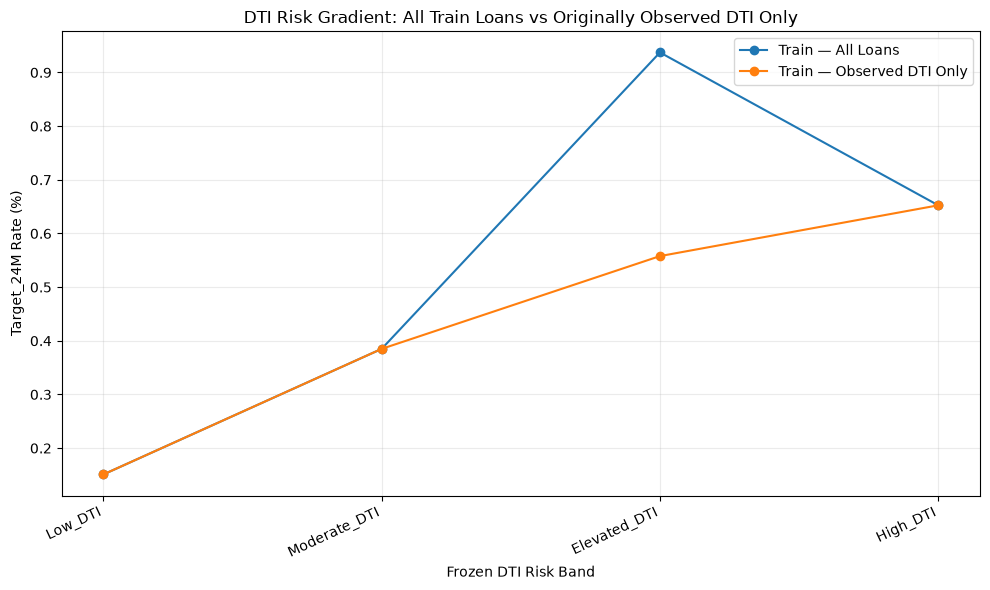

Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\part_2B_DTI_missingness_sensitivity\06A_2B_train_all_vs_observed_DTI_gradient.png


In [30]:
# ======================================================================================
# PLOT — TRAIN ALL vs TRAIN OBSERVED-DTI-ONLY
# ======================================================================================

plot_df = train_comparison.copy()

x = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    plot_df["All_Target_Rate_Pct"],
    marker="o",
    label="Train — All Loans",
)

plt.plot(
    x,
    plot_df["Observed_Target_Rate_Pct"],
    marker="o",
    label="Train — Observed DTI Only",
)

plt.xticks(
    x,
    plot_df["_DTI_Risk_Band_Audit"].astype(str),
    rotation=25,
    ha="right",
)

plt.xlabel("Frozen DTI Risk Band")
plt.ylabel("Target_24M Rate (%)")
plt.title(
    "DTI Risk Gradient: All Train Loans vs Originally Observed DTI Only"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plot_path = QA_DIR / "06A_2B_train_all_vs_observed_DTI_gradient.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

In [31]:
# ======================================================================================
# COMPARE ORIGINALLY MISSING DTI AGAINST TRUE OBSERVED-DTI BANDS
# ======================================================================================

train = analysis[analysis["Split"].eq("Train")].copy()

train_missing = train[
    train["_DTI_Missing_Status"].eq("Missing")
]

train_observed = train[
    train["_DTI_Missing_Status"].eq("Observed")
]

missing_summary = pd.DataFrame({
    "Group": ["Missing_DTI"],
    "N": [len(train_missing)],
    "Events": [train_missing["Target_24M"].sum()],
    "Target_Rate": [train_missing["Target_24M"].mean()],
})

observed_band_summary = (
    train_observed
    .groupby("_DTI_Risk_Band_Audit", observed=True)
    .agg(
        N=("Target_24M", "size"),
        Events=("Target_24M", "sum"),
        Target_Rate=("Target_24M", "mean"),
    )
    .reset_index()
    .rename(columns={"_DTI_Risk_Band_Audit": "Group"})
)

dti_group_comparison = pd.concat(
    [observed_band_summary, missing_summary],
    ignore_index=True,
)

dti_group_comparison["Target_Rate_Pct"] = (
    100 * dti_group_comparison["Target_Rate"]
)

print("Train: true observed DTI bands + Missing_DTI as separate information state")
display(dti_group_comparison)

dti_group_comparison.to_csv(
    QA_DIR / "06A_2B_train_observed_bands_plus_missing_DTI.csv",
    index=False,
)

Train: true observed DTI bands + Missing_DTI as separate information state


,Group,N,Events,Target_Rate,Target_Rate_Pct
0,Low_DTI,25839,39,0.001509,0.150935
1,Moderate_DTI,43382,167,0.003850,0.384952
2,Elevated_DTI,26351,147,0.005579,0.557854
3,High_DTI,48430,316,0.006525,0.652488
4,Missing_DTI,16001,250,0.015624,1.562402


In [32]:
# ======================================================================================
# CANDIDATE ADJUSTED DTI BAND
#
# Missing_DTI becomes its own category rather than inheriting the
# median-imputed Elevated_DTI category.
#
# DIAGNOSTIC ONLY — NOT WRITTEN TO PRODUCTION DATASET.
# ======================================================================================

adjusted_order = [
    "Low_DTI",
    "Moderate_DTI",
    "Elevated_DTI",
    "High_DTI",
    "Missing_DTI",
]

df["_DTI_Risk_Band_Adjusted_Candidate"] = (
    df["_DTI_Risk_Band_Audit"]
    .astype("string")
)

df.loc[
    df["_DTI_Missing_Status"].eq("Missing"),
    "_DTI_Risk_Band_Adjusted_Candidate"
] = "Missing_DTI"

df["_DTI_Risk_Band_Adjusted_Candidate"] = pd.Categorical(
    df["_DTI_Risk_Band_Adjusted_Candidate"],
    categories=adjusted_order,
    ordered=False,
)

adjusted_analysis = df[
    df["Split"].isin(["Train", "Validation"])
].copy()

adjusted_table = (
    adjusted_analysis
    .groupby(
        ["Split", "_DTI_Risk_Band_Adjusted_Candidate"],
        observed=True
    )
    .agg(
        N=("Target_24M", "size"),
        Events=("Target_24M", "sum"),
        Target_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

adjusted_table["Target_Rate_Pct"] = (
    100 * adjusted_table["Target_Rate"]
)

print("Candidate DTI_Risk_Band_Adjusted:")
display(adjusted_table)

adjusted_table.to_csv(
    QA_DIR / "06A_2B_DTI_Risk_Band_Adjusted_candidate.csv",
    index=False,
)

Candidate DTI_Risk_Band_Adjusted:


,Split,_DTI_Risk_Band_Adjusted_Candidate,N,Events,Target_Rate,Target_Rate_Pct
0,Train,Low_DTI,25839,39,0.001509,0.150935
1,Train,Moderate_DTI,43382,167,0.003850,0.384952
2,Train,Elevated_DTI,26351,147,0.005579,0.557854
3,Train,High_DTI,48430,316,0.006525,0.652488
4,Train,Missing_DTI,16001,250,0.015624,1.562402
5,Validation,Low_DTI,7030,23,0.003272,0.327169
6,Validation,Moderate_DTI,13413,69,0.005144,0.514426
7,Validation,Elevated_DTI,8637,72,0.008336,0.833623
8,Validation,High_DTI,18364,194,0.010564,1.056415
9,Validation,Missing_DTI,1594,22,0.013802,1.380176


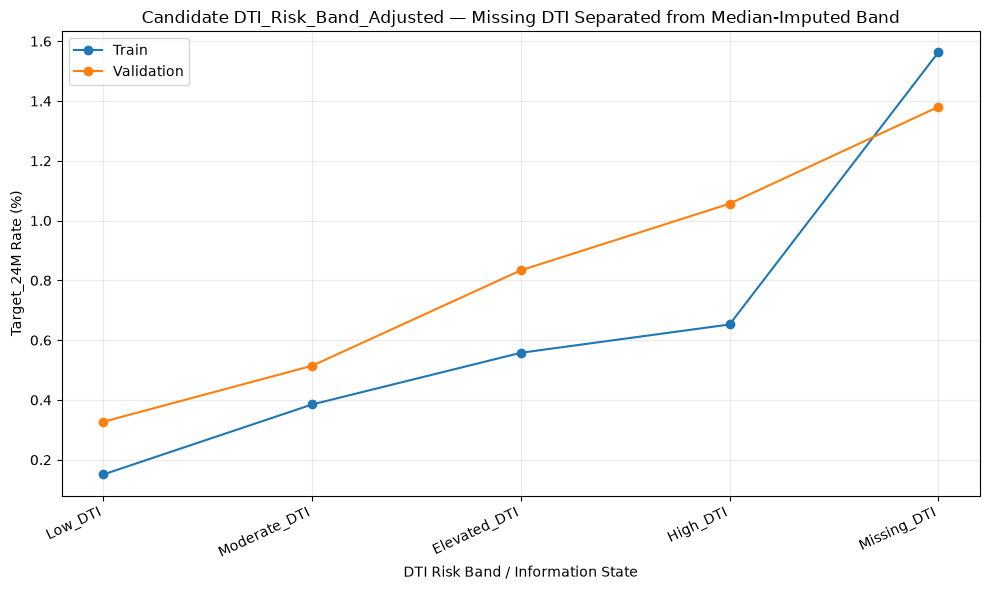

In [33]:
# ======================================================================================
# PLOT — ADJUSTED CANDIDATE
# ======================================================================================

plt.figure(figsize=(10, 6))

for split in ["Train", "Validation"]:
    temp = adjusted_table[
        adjusted_table["Split"].eq(split)
    ].copy()

    temp["_order"] = temp[
        "_DTI_Risk_Band_Adjusted_Candidate"
    ].map({
        name: i for i, name in enumerate(adjusted_order)
    })

    temp = temp.sort_values("_order")

    plt.plot(
        temp["_DTI_Risk_Band_Adjusted_Candidate"].astype(str),
        temp["Target_Rate_Pct"],
        marker="o",
        label=split,
    )

plt.xlabel("DTI Risk Band / Information State")
plt.ylabel("Target_24M Rate (%)")
plt.title(
    "Candidate DTI_Risk_Band_Adjusted — "
    "Missing DTI Separated from Median-Imputed Band"
)
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

adjusted_plot_path = (
    QA_DIR / "06A_2B_DTI_Risk_Band_Adjusted_candidate.png"
)

plt.savefig(
    adjusted_plot_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [34]:
# ======================================================================================
# AUTOMATED DIAGNOSTIC
# ======================================================================================

train_obs_rates = (
    observed_gradient[
        observed_gradient["Split"].eq("Train")
    ]
    .set_index("_DTI_Risk_Band_Audit")["Target_Rate"]
)

train_all_rates = (
    train_comparison
    .set_index("_DTI_Risk_Band_Audit")["All_Target_Rate"]
)

required_bands = [
    "Low_DTI",
    "Moderate_DTI",
    "Elevated_DTI",
    "High_DTI",
]

for band in required_bands:
    assert band in train_obs_rates.index, (
        f"Observed-only Train gradient missing band: {band}"
    )

all_nonmonotonic_tail = (
    train_all_rates.loc["Elevated_DTI"]
    >
    train_all_rates.loc["High_DTI"]
)

observed_nonmonotonic_tail = (
    train_obs_rates.loc["Elevated_DTI"]
    >
    train_obs_rates.loc["High_DTI"]
)

observed_monotonic = (
    train_obs_rates.loc["Low_DTI"]
    <= train_obs_rates.loc["Moderate_DTI"]
    <= train_obs_rates.loc["Elevated_DTI"]
    <= train_obs_rates.loc["High_DTI"]
)

train_missing_rate = train_missing["Target_24M"].mean()
train_observed_rate = train_observed["Target_24M"].mean()

diagnostic = {
    "train_all_has_35_39_gt_40plus": bool(all_nonmonotonic_tail),
    "train_observed_only_has_35_39_gt_40plus": bool(
        observed_nonmonotonic_tail
    ),
    "train_observed_only_monotonic": bool(observed_monotonic),
    "train_missing_DTI_target_rate": float(train_missing_rate),
    "train_observed_DTI_target_rate": float(train_observed_rate),
    "train_missing_DTI_relative_risk_vs_observed": (
        float(train_missing_rate / train_observed_rate)
        if train_observed_rate > 0
        else None
    ),
    "originally_missing_DTI_rows_all_data": int(missing_dti_rows.sum()),
    "originally_missing_DTI_now_equal_35": int(n_missing_at_35),
    "pct_originally_missing_DTI_now_equal_35": float(pct_missing_at_35),
}

print("Automated diagnostic:")
print(json.dumps(diagnostic, indent=2))

(QA_DIR / "06A_2B_DTI_missingness_diagnostic.json").write_text(
    json.dumps(diagnostic, indent=2),
    encoding="utf-8",
)

Automated diagnostic:
{
  "train_all_has_35_39_gt_40plus": true,
  "train_observed_only_has_35_39_gt_40plus": false,
  "train_observed_only_monotonic": true,
  "train_missing_DTI_target_rate": 0.015624023498531342,
  "train_observed_DTI_target_rate": 0.004645768808766545,
  "train_missing_DTI_relative_risk_vs_observed": 3.3630652194850676,
  "originally_missing_DTI_rows_all_data": 78026,
  "originally_missing_DTI_now_equal_35": 78026,
  "pct_originally_missing_DTI_now_equal_35": 100.0
}


469

In [35]:
# ======================================================================================
# DECISION-SUPPORT SUMMARY
#
# IMPORTANT:
# This does NOT automatically choose the final feature architecture.
# It summarizes the evidence for the next modeling decision.
# ======================================================================================

if all_nonmonotonic_tail and not observed_nonmonotonic_tail:
    interpretation = (
        "The Train 35–39 > 40+ reversal disappears after excluding "
        "originally missing DTI observations. This is evidence that "
        "median-imputed DTI materially affects the apparent DTI risk gradient."
    )
elif all_nonmonotonic_tail and observed_nonmonotonic_tail:
    interpretation = (
        "The Train 35–39 > 40+ reversal remains even when only originally "
        "observed DTI values are used. Therefore, the non-monotonic tail "
        "cannot be attributed solely to median imputation."
    )
else:
    interpretation = (
        "The Train DTI gradient does not show the previously identified "
        "35–39 > 40+ reversal under the current audit reconstruction."
    )


if observed_monotonic:
    architecture_note = (
        "Observed DTI exhibits a monotonic Train risk gradient. "
        "A separate Missing_DTI information state is therefore especially "
        "interpretable and should be evaluated as a challenger feature."
    )
else:
    architecture_note = (
        "Observed DTI itself is not fully monotonic. Missingness should still "
        "remain explicitly represented, but separating Missing_DTI does not "
        "by itself resolve all DTI-band instability."
    )


print("\n" + "=" * 100)
print("06A PART 2B — DECISION SUPPORT")
print("=" * 100)

print("\n1. Imputation sensitivity:")
print(interpretation)

print("\n2. Feature architecture:")
print(architecture_note)

print("\n3. Candidate designs to carry forward:")
print("   Design A:")
print("      Original_DTI")
print("      + DTI_Risk_Band")
print("      + DTI_Missing")

print("\n   Design B (challenger):")
print("      Original_DTI")
print("      + DTI_Missing")
print("      + DTI_Risk_Band_Adjusted")
print("        where originally missing DTI -> Missing_DTI category")

print("\n4. No production feature is created in Part 2B.")
print("5. No cutoff is re-optimized using Validation.")
print("6. OOT is not used.")


06A PART 2B — DECISION SUPPORT

1. Imputation sensitivity:
The Train 35–39 > 40+ reversal disappears after excluding originally missing DTI observations. This is evidence that median-imputed DTI materially affects the apparent DTI risk gradient.

2. Feature architecture:
Observed DTI exhibits a monotonic Train risk gradient. A separate Missing_DTI information state is therefore especially interpretable and should be evaluated as a challenger feature.

3. Candidate designs to carry forward:
   Design A:
      Original_DTI
      + DTI_Risk_Band
      + DTI_Missing

   Design B (challenger):
      Original_DTI
      + DTI_Missing
      + DTI_Risk_Band_Adjusted
        where originally missing DTI -> Missing_DTI category

4. No production feature is created in Part 2B.
5. No cutoff is re-optimized using Validation.
6. OOT is not used.


In [36]:
# ======================================================================================
# FINAL QA SUMMARY
# ======================================================================================

summary = {
    "stage": "06A_Part_2B_DTI_Missingness_Sensitivity_Audit",
    "input_file": str(INPUT.name),
    "rows": int(len(df)),
    "unique_loans": int(df["Loan_ID"].nunique()),
    "train_rows": int((df["Split"] == "Train").sum()),
    "validation_rows": int((df["Split"] == "Validation").sum()),
    "oot_used": False,
    "cutoffs_reoptimized": False,
    "production_dataset_modified": False,
    "frozen_DTI_cutoffs": [25, 35, 40],
    "diagnostic": diagnostic,
    "interpretation": interpretation,
    "architecture_note": architecture_note,
}

summary_path = QA_DIR / "06A_2B_summary.json"

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 100)
print("06A PART 2B COMPLETE")
print("=" * 100)

print(f"Rows audited                : {len(df):,}")
print(f"Train rows                  : {(df['Split'] == 'Train').sum():,}")
print(f"Validation rows             : {(df['Split'] == 'Validation').sum():,}")
print(f"Originally missing DTI      : {missing_dti_rows.sum():,}")
print(f"Missing DTI now at 35       : {n_missing_at_35:,}")
print(f"Observed-only monotonic     : {observed_monotonic}")
print(f"OOT used                    : NO")
print(f"Validation optimized on     : NO")
print(f"Cutoffs changed             : NO")
print(f"Production dataset modified : NO")
print("\nQA artifacts:")
print(QA_DIR.resolve())


06A PART 2B COMPLETE
Rows audited                : 713,000
Train rows                  : 160,003
Validation rows             : 49,038
Originally missing DTI      : 78,026
Missing DTI now at 35       : 78,026
Observed-only monotonic     : True
OOT used                    : NO
Validation optimized on     : NO
Cutoffs changed             : NO
Production dataset modified : NO

QA artifacts:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\06A_risk_band_cutoff_discovery\part_2B_DTI_missingness_sensitivity


Required columns: PASS

Observed DTI_Missing values:
DTI_Missing_Audit
Observed    634974
Missing      78026
Name: count, dtype: int64[pyarrow]

Observed HARP values:
HARP_Audit
N    635029
Y     77971
Name: count, dtype: int64[pyarrow]

Observed Split values:
Split_Audit
Other Period    404240
Train           160003
OOT Test         99719
Validation       49038
Name: count, dtype: int64[pyarrow]

Post-imputation DTI integrity check:


,metric,value
0,Total rows,713000.0
1,Current Original_DTI NA,0.0
2,DTI_Missing == Missing,78026.0
3,DTI_Missing == Observed,634974.0
4,Originally missing rows now equal Train median...,78026.0
5,% originally missing rows now equal Train medi...,100.0



PASS — Post-imputation DTI structure is internally consistent.
NOTE — DTI_Missing is intentionally NOT compared with Original_DTI.isna(), because Original_DTI has already been imputed.

Train rows      : 160,003
Validation rows : 49,038

TRAIN — HARP × DTI Missingness: Counts


DTI_Missing_Audit,Observed,Missing,All
HARP_Audit,,,
N,144002,8,144010
Y,0,15993,15993
All,144002,16001,160003



TRAIN — P(DTI Missing | HARP)


...


TRAIN — HARP × DTI Missingness: Four-Cell Risk Table


,HARP_Audit,DTI_Missing_Audit,N,Target_24M_Events,Target_24M_Rate,Target_24M_Rate_pct
0,N,Missing,8,0,0.000000,0.000000
1,N,Observed,144002,669,0.004646,0.464577
2,Y,Missing,15993,250,0.015632,1.563184



TRAIN — HARP / DTI Missingness Association


,metric,value
0,P(DTI Missing | HARP=Y),1.000000
1,P(DTI Missing | HARP=N),0.000056
2,Absolute difference,0.999944
3,Relative ratio: Y / N,18001.250000


P(DTI Missing | HARP=Y) = 100.0000%
P(DTI Missing | HARP=N) = 0.0056%
Missingness ratio (HARP Y / HARP N) = 18001.25x


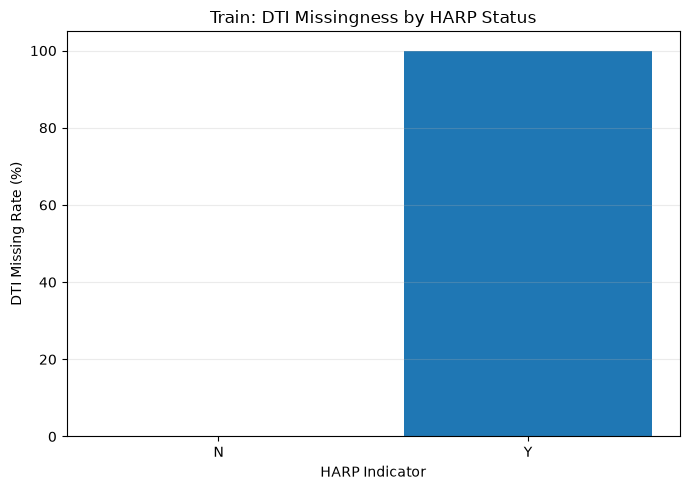

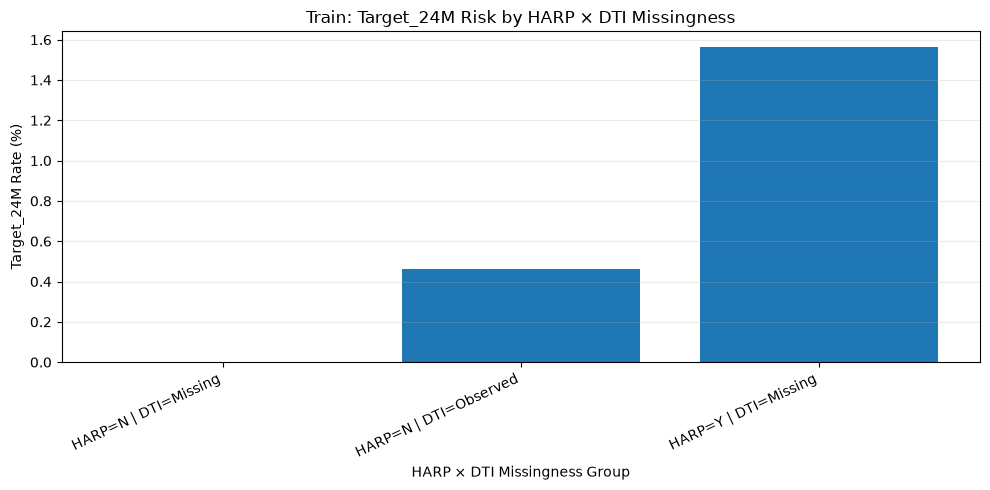


VALIDATION CONFIRMATION — P(DTI Missing | HARP)
Validation is NOT used for feature-definition optimization.


,HARP_Audit,N,DTI_Missing_N,P_DTI_Missing,P_DTI_Missing_pct
0,N,47446,2,0.000042,0.004215
1,Y,1592,1592,1.000000,100.000000



VALIDATION — Four-cell risk table:


,HARP_Audit,DTI_Missing_Audit,N,Target_24M_Events,Target_24M_Rate,Target_24M_Rate_pct
0,N,Missing,2,0,0.000000,0.000000
1,N,Observed,47444,358,0.007546,0.754574
2,Y,Missing,1592,22,0.013819,1.381910



TRAIN vs VALIDATION — HARP / DTI Missingness Confirmation


,Split,HARP_Audit,N,DTI_Missing_N,DTI_Missing_Rate,DTI_Missing_Rate_pct
0,Train,N,144010,8,0.000056,0.005555
1,Train,Y,15993,15993,1.000000,100.000000
2,Validation,N,47446,2,0.000042,0.004215
3,Validation,Y,1592,1592,1.000000,100.000000



CHALLENGER AUDIT — HARP × DTI_Missing Candidate


,HARP_x_DTI_Missing_Candidate,N,Target_24M_Events,Target_24M_Rate,Target_24M_Rate_pct
0,0,144010,669,0.004646,0.464551
1,1,15993,250,0.015632,1.563184



06A PART 2B — HARP × DTI MISSINGNESS AUDIT COMPLETE
Train rows analyzed       : 160,003
Validation rows confirmed : 49,038
OOT used                  : NO
Production dataset changed: NO

Primary quantity:
  P(DTI Missing | HARP=Y) vs P(DTI Missing | HARP=N)

Candidate challenger:
  HARP_x_DTI_Missing = 1 if HARP=Y AND DTI_Missing=Missing

Interpretation rule: DTI missingness is treated as an information/reporting-state indicator, NOT as unemployment.


In [37]:
# =============================================================================
# 06A PART 2B
# HARP × DTI Missingness Audit
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------------------------------------------------------
# 1. Required-column checks
# -----------------------------------------------------------------------------

REQUIRED_COLS = [
    "Split",
    "Target_24M",
    "Original_DTI",
    "DTI_Missing",
    "HARP_Indicator",
]

missing_required = [c for c in REQUIRED_COLS if c not in df.columns]

assert not missing_required, (
    f"Missing required columns: {missing_required}"
)

print("Required columns: PASS")


# -----------------------------------------------------------------------------
# 2. Normalize audit variables WITHOUT modifying production columns
# -----------------------------------------------------------------------------

audit = df[
    [
        "Split",
        "Target_24M",
        "Original_DTI",
        "DTI_Missing",
        "HARP_Indicator",
    ]
].copy()

audit["Split_Audit"] = (
    audit["Split"]
    .astype("string")
    .str.strip()
)

audit["HARP_Audit"] = (
    audit["HARP_Indicator"]
    .astype("string")
    .str.strip()
    .str.upper()
)

audit["DTI_Missing_Audit"] = (
    audit["DTI_Missing"]
    .astype("string")
    .str.strip()
)

# Standardize DTI missing indicator if necessary
dti_map = {
    "Observed": "Observed",
    "Missing": "Missing",
    "OBSERVED": "Observed",
    "MISSING": "Missing",
    "0": "Observed",
    "1": "Missing",
    "False": "Observed",
    "True": "Missing",
    "FALSE": "Observed",
    "TRUE": "Missing",
}

audit["DTI_Missing_Audit"] = (
    audit["DTI_Missing_Audit"]
    .replace(dti_map)
)

print("\nObserved DTI_Missing values:")
print(audit["DTI_Missing_Audit"].value_counts(dropna=False))

print("\nObserved HARP values:")
print(audit["HARP_Audit"].value_counts(dropna=False))

print("\nObserved Split values:")
print(audit["Split_Audit"].value_counts(dropna=False))


# -----------------------------------------------------------------------------
# 3. Post-imputation integrity check
#
# IMPORTANT:
# Original_DTI has already been imputed in the missing-value treatment stage.
# Therefore:
#
#   Original_DTI.isna()
#
# is NOT expected to agree with DTI_Missing.
#
# DTI_Missing is a PRE-IMPUTATION missingness indicator retained so that
# information about the original missing DTI is not lost after median
# imputation.
#
# Expected structure:
#   DTI_Missing == "Observed" -> Original_DTI contains observed/treatment value
#   DTI_Missing == "Missing"  -> Original_DTI contains Train-median imputation
#
# From the frozen missing-value treatment:
#   Train median for Original_DTI = 35
# -----------------------------------------------------------------------------

DTI_IMPUTATION_VALUE = 35.0

indicator_missing = (
    audit["DTI_Missing_Audit"].eq("Missing")
)

indicator_observed = (
    audit["DTI_Missing_Audit"].eq("Observed")
)

# Current dataset is post-imputation, so treated DTI should contain no NA.
remaining_dti_na = audit["Original_DTI"].isna().sum()

# Among rows marked as originally missing, inspect the treated values.
missing_indicator_values = pd.to_numeric(
    audit.loc[indicator_missing, "Original_DTI"],
    errors="coerce"
)

n_originally_missing = int(indicator_missing.sum())

n_missing_imputed_to_35 = int(
    missing_indicator_values.eq(DTI_IMPUTATION_VALUE).sum()
)

pct_missing_imputed_to_35 = (
    100 * n_missing_imputed_to_35 / n_originally_missing
    if n_originally_missing > 0
    else np.nan
)

dti_indicator_check = pd.DataFrame({
    "metric": [
        "Total rows",
        "Current Original_DTI NA",
        "DTI_Missing == Missing",
        "DTI_Missing == Observed",
        "Originally missing rows now equal Train median (35)",
        "% originally missing rows now equal Train median (35)",
    ],
    "value": [
        len(audit),
        int(remaining_dti_na),
        n_originally_missing,
        int(indicator_observed.sum()),
        n_missing_imputed_to_35,
        pct_missing_imputed_to_35,
    ]
})

print("\nPost-imputation DTI integrity check:")
display(dti_indicator_check)


# Current treated dataset should contain no remaining Original_DTI missingness.
assert remaining_dti_na == 0, (
    f"Original_DTI still contains {remaining_dti_na:,} missing values "
    "after the missing-value treatment stage."
)


# DTI_Missing itself must be fully interpretable.
assert (
    indicator_missing | indicator_observed
).all(), (
    "DTI_Missing contains values other than the expected "
    "'Missing' / 'Observed' states."
)


print("\nPASS — Post-imputation DTI structure is internally consistent.")
print(
    "NOTE — DTI_Missing is intentionally NOT compared with "
    "Original_DTI.isna(), because Original_DTI has already been imputed."
)


# -----------------------------------------------------------------------------
# 4. Restrict decision-making analysis to TRAIN
# -----------------------------------------------------------------------------

train = audit.loc[
    audit["Split_Audit"].eq("Train")
].copy()

validation = audit.loc[
    audit["Split_Audit"].eq("Validation")
].copy()

assert len(train) > 0, "No Train rows found."
assert len(validation) > 0, "No Validation rows found."

print(f"\nTrain rows      : {len(train):,}")
print(f"Validation rows : {len(validation):,}")


# -----------------------------------------------------------------------------
# 5. TRAIN: HARP × DTI Missing count table
# -----------------------------------------------------------------------------

train_count_table = pd.crosstab(
    train["HARP_Audit"],
    train["DTI_Missing_Audit"],
    margins=True
)

# Reorder where possible
desired_cols = ["Observed", "Missing", "All"]
train_count_table = train_count_table.reindex(
    columns=[c for c in desired_cols if c in train_count_table.columns]
)

print("\n" + "=" * 90)
print("TRAIN — HARP × DTI Missingness: Counts")
print("=" * 90)

display(train_count_table)


# -----------------------------------------------------------------------------
# 6. TRAIN:
#    P(DTI Missing | HARP status)
# -----------------------------------------------------------------------------

train_missing_probability = (
    train.assign(
        DTI_Is_Missing=train["DTI_Missing_Audit"].eq("Missing").astype(int)
    )
    .groupby("HARP_Audit", dropna=False)
    .agg(
        N=("Target_24M", "size"),
        DTI_Missing_N=("DTI_Is_Missing", "sum"),
        P_DTI_Missing=("DTI_Is_Missing", "mean"),
    )
    .reset_index()
)

train_missing_probability["P_DTI_Missing_pct"] = (
    100 * train_missing_probability["P_DTI_Missing"]
)

print("\n" + "=" * 90)
print("TRAIN — P(DTI Missing | HARP)")
print("=" * 90)

display(train_missing_probability)


# -----------------------------------------------------------------------------
# 7. TRAIN:
#    Four-cell N / Events / Target Rate
# -----------------------------------------------------------------------------

train_four_cell = (
    train
    .groupby(
        ["HARP_Audit", "DTI_Missing_Audit"],
        dropna=False
    )
    .agg(
        N=("Target_24M", "size"),
        Target_24M_Events=("Target_24M", "sum"),
        Target_24M_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

train_four_cell["Target_24M_Rate_pct"] = (
    100 * train_four_cell["Target_24M_Rate"]
)

train_four_cell = train_four_cell[
    [
        "HARP_Audit",
        "DTI_Missing_Audit",
        "N",
        "Target_24M_Events",
        "Target_24M_Rate",
        "Target_24M_Rate_pct",
    ]
]

print("\n" + "=" * 90)
print("TRAIN — HARP × DTI Missingness: Four-Cell Risk Table")
print("=" * 90)

display(train_four_cell)


# -----------------------------------------------------------------------------
# 8. Direct comparison:
#    P(Missing | HARP=Y) / P(Missing | HARP=N)
# -----------------------------------------------------------------------------

prob_lookup = (
    train_missing_probability
    .set_index("HARP_Audit")["P_DTI_Missing"]
)

p_missing_harp_y = (
    float(prob_lookup.loc["Y"])
    if "Y" in prob_lookup.index
    else np.nan
)

p_missing_harp_n = (
    float(prob_lookup.loc["N"])
    if "N" in prob_lookup.index
    else np.nan
)

absolute_difference = (
    p_missing_harp_y - p_missing_harp_n
    if pd.notna(p_missing_harp_y) and pd.notna(p_missing_harp_n)
    else np.nan
)

relative_ratio = (
    p_missing_harp_y / p_missing_harp_n
    if (
        pd.notna(p_missing_harp_y)
        and pd.notna(p_missing_harp_n)
        and p_missing_harp_n > 0
    )
    else np.nan
)

harp_dti_comparison = pd.DataFrame({
    "metric": [
        "P(DTI Missing | HARP=Y)",
        "P(DTI Missing | HARP=N)",
        "Absolute difference",
        "Relative ratio: Y / N",
    ],
    "value": [
        p_missing_harp_y,
        p_missing_harp_n,
        absolute_difference,
        relative_ratio,
    ],
})

print("\n" + "=" * 90)
print("TRAIN — HARP / DTI Missingness Association")
print("=" * 90)

display(harp_dti_comparison)

if pd.notna(p_missing_harp_y):
    print(
        f"P(DTI Missing | HARP=Y) = "
        f"{p_missing_harp_y:.4%}"
    )

if pd.notna(p_missing_harp_n):
    print(
        f"P(DTI Missing | HARP=N) = "
        f"{p_missing_harp_n:.4%}"
    )

if pd.notna(relative_ratio):
    print(
        f"Missingness ratio (HARP Y / HARP N) = "
        f"{relative_ratio:.2f}x"
    )


# -----------------------------------------------------------------------------
# 9. TRAIN visualization
# -----------------------------------------------------------------------------

plot_df = train_missing_probability[
    train_missing_probability["HARP_Audit"].isin(["N", "Y"])
].copy()

plt.figure(figsize=(7, 5))

plt.bar(
    plot_df["HARP_Audit"],
    plot_df["P_DTI_Missing_pct"]
)

plt.xlabel("HARP Indicator")
plt.ylabel("DTI Missing Rate (%)")
plt.title("Train: DTI Missingness by HARP Status")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 10. TRAIN target-risk visualization for four cells
# -----------------------------------------------------------------------------

plot_four = train_four_cell[
    train_four_cell["HARP_Audit"].isin(["N", "Y"])
].copy()

plot_four["Group"] = (
    "HARP=" + plot_four["HARP_Audit"].astype(str)
    + " | DTI=" + plot_four["DTI_Missing_Audit"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_four["Group"],
    plot_four["Target_24M_Rate_pct"]
)

plt.ylabel("Target_24M Rate (%)")
plt.xlabel("HARP × DTI Missingness Group")
plt.title(
    "Train: Target_24M Risk by HARP × DTI Missingness"
)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 11. VALIDATION CONFIRMATION
#     Validation is NOT used to define or optimize the feature.
# -----------------------------------------------------------------------------

validation_summary = (
    validation
    .assign(
        DTI_Is_Missing=
        validation["DTI_Missing_Audit"].eq("Missing").astype(int)
    )
    .groupby("HARP_Audit", dropna=False)
    .agg(
        N=("Target_24M", "size"),
        DTI_Missing_N=("DTI_Is_Missing", "sum"),
        P_DTI_Missing=("DTI_Is_Missing", "mean"),
    )
    .reset_index()
)

validation_summary["P_DTI_Missing_pct"] = (
    100 * validation_summary["P_DTI_Missing"]
)

print("\n" + "=" * 90)
print("VALIDATION CONFIRMATION — P(DTI Missing | HARP)")
print("Validation is NOT used for feature-definition optimization.")
print("=" * 90)

display(validation_summary)


validation_four_cell = (
    validation
    .groupby(
        ["HARP_Audit", "DTI_Missing_Audit"],
        dropna=False
    )
    .agg(
        N=("Target_24M", "size"),
        Target_24M_Events=("Target_24M", "sum"),
        Target_24M_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

validation_four_cell["Target_24M_Rate_pct"] = (
    100 * validation_four_cell["Target_24M_Rate"]
)

print("\nVALIDATION — Four-cell risk table:")
display(validation_four_cell)


# -----------------------------------------------------------------------------
# 12. Combined Train / Validation confirmation table
# -----------------------------------------------------------------------------

def build_split_summary(data, split_name):
    out = (
        data
        .assign(
            DTI_Is_Missing=
            data["DTI_Missing_Audit"].eq("Missing").astype(int)
        )
        .groupby("HARP_Audit", dropna=False)
        .agg(
            N=("Target_24M", "size"),
            DTI_Missing_N=("DTI_Is_Missing", "sum"),
            DTI_Missing_Rate=("DTI_Is_Missing", "mean"),
        )
        .reset_index()
    )

    out.insert(0, "Split", split_name)
    out["DTI_Missing_Rate_pct"] = (
        100 * out["DTI_Missing_Rate"]
    )

    return out


train_validation_confirmation = pd.concat(
    [
        build_split_summary(train, "Train"),
        build_split_summary(validation, "Validation"),
    ],
    ignore_index=True
)

print("\n" + "=" * 90)
print("TRAIN vs VALIDATION — HARP / DTI Missingness Confirmation")
print("=" * 90)

display(train_validation_confirmation)


# -----------------------------------------------------------------------------
# 13. Candidate interaction flag — AUDIT ONLY
#
# DO NOT write this into production dataset yet.
# We first determine whether the interaction contains useful information.
# -----------------------------------------------------------------------------

train["HARP_x_DTI_Missing_Candidate"] = (
    train["HARP_Audit"].eq("Y")
    & train["DTI_Missing_Audit"].eq("Missing")
).astype("int8")

candidate_summary = (
    train
    .groupby("HARP_x_DTI_Missing_Candidate")
    .agg(
        N=("Target_24M", "size"),
        Target_24M_Events=("Target_24M", "sum"),
        Target_24M_Rate=("Target_24M", "mean"),
    )
    .reset_index()
)

candidate_summary["Target_24M_Rate_pct"] = (
    100 * candidate_summary["Target_24M_Rate"]
)

print("\n" + "=" * 90)
print("CHALLENGER AUDIT — HARP × DTI_Missing Candidate")
print("=" * 90)

display(candidate_summary)


# -----------------------------------------------------------------------------
# 14. Final audit statement
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("06A PART 2B — HARP × DTI MISSINGNESS AUDIT COMPLETE")
print("=" * 100)

print(f"Train rows analyzed       : {len(train):,}")
print(f"Validation rows confirmed : {len(validation):,}")
print("OOT used                  : NO")
print("Production dataset changed: NO")
print()
print("Primary quantity:")
print("  P(DTI Missing | HARP=Y) vs P(DTI Missing | HARP=N)")
print()
print("Candidate challenger:")
print("  HARP_x_DTI_Missing = 1 if HARP=Y AND DTI_Missing=Missing")
print()
print(
    "Interpretation rule: DTI missingness is treated as an "
    "information/reporting-state indicator, NOT as unemployment."
)

Original_DTI is treated separately because its pre-imputation missingness (10.94%) is materially larger and structurally related to HARP, whereas missingness in the other median-imputed loan variables is negligible (≤0.014%) and residual missingness in the final LS macro variables is approximately 0.047%.